# GENESIS MSP Database — Discourse Pattern Analysis
## Unsupervised Topic Modelling with BERTopic

**Dataset:** GENESIS WP4 Database on Multistakeholder Partnerships (V1, Dec 2025)
**N = 3,807** projects with sufficient textual content (combined title + description > 100 characters)

**Research Questions:**
1. What discourse clusters emerge among SDG partnership projects?
2. How do validated projects differ structurally and lexically from non-validated ones?
3. Which SDG domains exhibit the greatest divergence between discourse and validation status (VDSI)?

**Pipeline:**
```
Text Cleaning → Sentence Transformers → UMAP → HDBSCAN → BERTopic
    → Validated vs Non-Validated Comparative Analysis → VDSI Index → SDG Subgroup Analysis
```

> **Data leakage protection:** `Type of Partnership`, `Type of project`,
> `SDG scope`, and `Status` are never used as model inputs.
> `Status` (Checked-In/Out) is used **only** as a post-hoc analytical label.
>
> **Checkpoint system:** CP1–CP16 cached to Google Drive.
> Each cell checks for existing checkpoints before recomputing.
>
> **Note on terminology:** Python identifiers (`is_validated`, `validated_df`, `VDSI`,
> `VDSI_cat`, `VDSI_SURPLUS_THRESH`, etc.) match the manuscript terminology
> (Validated / Non-validated; VDSI) throughout, in both internal code and
> reader-facing text, figures, and tables.


## 1. Installation & Setup


In [1]:
# ── Determinism: force single-threaded BLAS before numpy/scipy/sklearn load ──
# Multi-threaded BLAS (OpenBLAS/MKL) can change floating-point summation order
# across runs, which cascades through UMAP/HDBSCAN's nearest-neighbour and
# distance computations even with random_state and n_jobs=1 fixed. Must be set
# BEFORE numpy is first imported (Cell 3) to take effect.
import os
os.environ["OMP_NUM_THREADS"]      = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"]      = "1"
os.environ["NUMEXPR_NUM_THREADS"]  = "1"
print("✓ Single-threaded BLAS environment variables set.")


✓ Single-threaded BLAS environment variables set.


In [2]:
# ── Package installation ──────────────────────────────────────────────────────
import subprocess, sys

pkgs = [
    "bertopic==0.16.4",
    "sentence-transformers==3.3.1",
    "umap-learn==0.5.7",
    "hdbscan==0.8.40",
    "plotly==5.24.1",
    "scikit-learn>=1.4",
    "gensim>=4.3.0",        # C_V topic coherence
    "statsmodels>=0.14.0",  # FDR multiple comparison correction
    "pandas", "numpy", "matplotlib", "seaborn",
    "joblib", "scipy",
    "anthropic",              # LLM topic labelling (optional, fallback if unavailable)
]
for pkg in pkgs:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", pkg],
        stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL
    )
print("✓ All packages installed.")
print("  Key packages: bertopic, sentence-transformers, umap-learn,")
print("  hdbscan, gensim (coherence), statsmodels (FDR)")


✓ All packages installed.
  Key packages: bertopic, sentence-transformers, umap-learn,
  hdbscan, gensim (coherence), statsmodels (FDR)


In [3]:
# ── Google Drive mount ────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

import os, glob, json, joblib, warnings
import numpy as np
import pandas as pd

# Suppress only known harmless third-party warnings; keep runtime errors visible
warnings.filterwarnings('ignore', category=FutureWarning,    module='sklearn')
warnings.filterwarnings('ignore', category=FutureWarning,    module='umap')
warnings.filterwarnings('ignore', category=FutureWarning,    module='hdbscan')
warnings.filterwarnings('ignore', category=DeprecationWarning, module='bertopic')
warnings.filterwarnings('ignore', category=UserWarning,      module='gensim')

PROJECT_ROOT   = '/content/drive/MyDrive/GENESIS_BERTopic'
CHECKPOINT_DIR = os.path.join(PROJECT_ROOT, 'checkpoints')
OUTPUT_DIR     = os.path.join(PROJECT_ROOT, 'outputs')
DATA_DIR       = os.path.join(PROJECT_ROOT, 'data')

for d in [PROJECT_ROOT, CHECKPOINT_DIR, OUTPUT_DIR, DATA_DIR]:
    os.makedirs(d, exist_ok=True)

print(f"✓ Project root : {PROJECT_ROOT}")
print(f"  ├── checkpoints/")
print(f"  ├── outputs/")
print(f"  └── data/")


Mounted at /content/drive
✓ Project root : /content/drive/MyDrive/GENESIS_BERTopic
  ├── checkpoints/
  ├── outputs/
  └── data/


In [4]:
# ── Global constants ──────────────────────────────────────────────────────────
import random

RANDOM_STATE   = 42
MIN_TEXT_LEN   = 100     # Minimum character length for BERTopic (excludes ~15% of corpus)
N_NEIGHBORS    = 15      # UMAP neighbours (standard BERTopic default)
N_COMPONENTS   = 5       # UMAP output dimensions for clustering
TOP_N_WORDS    = 10      # Words per topic (c-TF-IDF)
DPI_SAVE       = 600     # SCIE minimum DPI

# BERTopic's nr_topics='auto' (hierarchical topic merging based on a
# similarity threshold) proved sensitive to microscopic floating-point
# differences propagated from UMAP/HDBSCAN, causing the final topic count to
# vary across otherwise-identical runs (5-8 topics observed). Fixing the
# target count removes this instability; 5 matches the topic structure
# (3 substantive + 2 non-English artifact clusters) already reported and
# reviewed in the manuscript.
TARGET_N_TOPICS = 5

# A4 double-column figure dimensions (inches)
FIG_W  = 7.0
FIG_H1 = 4.5
FIG_H2 = 9.0

# ── VDSI threshold constants (±0.30 ≈ 1 SD of non-validated sim_norm) ────────
VDSI_SURPLUS_THRESH =  0.30
VDSI_DEFICIT_THRESH = -0.30
VDSI_CONSIST_HI     =  0.10
VDSI_CONSIST_LO     = -0.10

# ── Topic label rules ────────────────────────────────────────────────────────
# Topics are classified automatically by their top keywords (order = priority),
# applied after BERTopic runs via auto_label_topics().
TOPIC_LABEL_RULES = [
    # Non-English artefacts — detected by function word dominance
    (['la', 'el', 'en', 'los', 'para', 'del', 'que', 'las', 'por', 'con'],
     'Non-English Cluster (ES)', 3),   # Spanish: 3+ matches needed
    (['des', 'et', 'la', 'les', 'en', 'le', 'du', 'pour', 'les', 'une'],
     'Non-English Cluster (FR)', 3),   # French: 3+ matches needed
    # Substantive English topics
    (['ocean', 'marine', 'fisheries', 'coastal', 'fishing', 'coral', 'plastic'],
     'Marine / Ocean / Fisheries', 2),
    (['fashion', 'textile', 'clothing', 'brand', 'garment', 'circular', 'waste'],
     'Fashion / Textile / Sustainable', 2),
    (['water', 'climate', 'health', 'development', 'sustainable', 'support'],
     'Water / Development / Sustainable', 2),
]

# Fallback: always keep outlier label
MANUAL_TOPIC_LABELS = {}   # populated dynamically in Cell 21


random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print(f"✓ Constants set | DPI={DPI_SAVE} | Fig={FIG_W}x{FIG_H1}in")
print(f"  UMAP: n_neighbors={N_NEIGHBORS}, n_components={N_COMPONENTS}")
print(f"  Manual topic label overrides: {MANUAL_TOPIC_LABELS}")


✓ Constants set | DPI=600 | Fig=7.0x4.5in
  UMAP: n_neighbors=15, n_components=5
  Manual topic label overrides: {}


In [5]:
# ── SCIE-ready matplotlib global style ───────────────────────────────────────
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

mpl.rcParams.update({
    'font.family'        : 'serif',
    'font.serif'         : ['Times New Roman', 'DejaVu Serif'],
    'font.size'          : 9,
    'axes.titlesize'     : 10,
    'axes.labelsize'     : 9,
    'xtick.labelsize'    : 8,
    'ytick.labelsize'    : 8,
    'legend.fontsize'    : 8,
    'figure.titlesize'   : 11,
    'axes.linewidth'     : 0.8,
    'grid.linewidth'     : 0.5,
    'lines.linewidth'    : 1.2,
    'axes.grid'          : True,
    'grid.alpha'         : 0.3,
    'grid.linestyle'     : '--',
    'savefig.bbox'       : 'tight',
    'savefig.dpi'        : DPI_SAVE,
    'savefig.format'     : 'png',
    'axes.prop_cycle'    : mpl.cycler(color=[
        '#1565C0','#B71C1C','#2E7D32','#6A1B9A',
        '#E65100','#00695C','#4E342E','#37474F']),
})
print("✓ SCIE matplotlib style loaded.")


✓ SCIE matplotlib style loaded.


## 2. Checkpoint System


In [6]:
# ── Checkpoint helpers ────────────────────────────────────────────────────────
from datetime import datetime

def save_checkpoint(obj, name: str, fmt: str = 'joblib') -> str:
    ts    = datetime.now().strftime('%Y%m%d_%H%M%S')
    ext   = {'joblib': '.pkl', 'json': '.json', 'pickle': '.pkl'}[fmt]
    fpath = os.path.join(CHECKPOINT_DIR, f"{name}_{ts}{ext}")
    if fmt == 'joblib':
        joblib.dump(obj, fpath, compress=3)
    elif fmt == 'json':
        with open(fpath, 'w', encoding='utf-8') as f:
            json.dump(obj, f, ensure_ascii=False, indent=2, default=str)
    elif fmt == 'pickle':
        import pickle
        with open(fpath, 'wb') as f:
            pickle.dump(obj, f)
    print(f"  ✓ Checkpoint saved → {os.path.basename(fpath)} "
          f"({os.path.getsize(fpath)/1024:.1f} KB)")
    return fpath

def load_latest(name: str, fmt: str = 'joblib'):
    ext   = {'joblib': '.pkl', 'json': '.json', 'pickle': '.pkl'}[fmt]
    files = sorted(glob.glob(os.path.join(CHECKPOINT_DIR, f"{name}_*{ext}")))
    if not files:
        return None
    fpath = files[-1]
    print(f"  ↩ Loading checkpoint: {os.path.basename(fpath)}")
    if fmt == 'joblib':
        return joblib.load(fpath)
    elif fmt == 'json':
        with open(fpath, 'r', encoding='utf-8') as f:
            return json.load(f)
    elif fmt == 'pickle':
        import pickle
        with open(fpath, 'rb') as f:
            return pickle.load(f)

def cp_exists(name: str, fmt: str = 'joblib') -> bool:
    ext   = {'joblib': '.pkl', 'json': '.json', 'pickle': '.pkl'}[fmt]
    files = glob.glob(os.path.join(CHECKPOINT_DIR, f"{name}_*{ext}"))
    return len(files) > 0

def list_checkpoints():
    files = sorted(glob.glob(os.path.join(CHECKPOINT_DIR, '*')))
    if not files:
        print("  No checkpoints yet.")
        return
    print(f"  {'Filename':<52} {'Size':>8}")
    print(f"  {'-'*52} {'-'*8}")
    for f in files:
        print(f"  {os.path.basename(f):<52} {os.path.getsize(f)/1024:>6.1f} KB")

print("✓ Checkpoint system ready.")


✓ Checkpoint system ready.


## 3. Data Loading & Preprocessing


In [7]:
# ── Data file path ────────────────────────────────────────────────────────────
import zipfile

ZIP_NAME = '17940564.zip'
CSV_NAME = ('2025.12.15–GENESIS–WP4–Database_on_Multistakeholder'
            '_Partnerships_for_Sustainable_Development–V1.csv')

zip_path = os.path.join(DATA_DIR, ZIP_NAME)
csv_path = os.path.join(DATA_DIR, CSV_NAME)

if not os.path.exists(csv_path):
    if os.path.exists(zip_path):
        print(f"Extracting: {zip_path}")
        with zipfile.ZipFile(zip_path, 'r') as z:
            z.extractall(DATA_DIR)
        found = [f for f in glob.glob(os.path.join(DATA_DIR, '*V1.csv'))
                 if 'Checked' not in f]
        csv_path = found[0] if found else csv_path
    else:
        raise FileNotFoundError(
            f"Please upload '{ZIP_NAME}' to: {DATA_DIR}")

DATA_PATH = csv_path
print(f"✓ Data path: {os.path.basename(DATA_PATH)}")


✓ Data path: 2025.12.15–GENESIS–WP4–Database_on_Multistakeholder_Partnerships_for_Sustainable_Development–V1.csv


In [8]:
# ── CP1: Load & clean raw data ────────────────────────────────────────────────
import re

def clean_text(text: str) -> str:
    if not isinstance(text, str) or not text.strip():
        return ''
    text = text.replace('\r\n', ' ').replace('\n', ' ')
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'<[^>]+>', ' ', text)
    # Latin-1 artifacts
    for bad, good in [('Ñ','-'),('Ê',' '),('Õ',"'"),('Ð','-'),('Ã','A')]:
        text = text.replace(bad, good)
    return re.sub(r'\s+', ' ', text).strip()

if cp_exists('cp1_df_processed'):
    print("✓ CP1 found → loading...")
    df = load_latest('cp1_df_processed')
    # Verify that text columns needed downstream are present
    _required = ['text', 'text_name', 'text_desc', 'is_validated',
                 'partner_count', 'sdg_count', 'desc_len', 'text_len']
    _missing = [c for c in _required if c not in df.columns]
    if _missing:
        print(f"  ⚠ Missing columns in CP1: {_missing}")
        print(f"  → Rebuilding from raw data (delete CP1 checkpoint and re-run).")
        raise RuntimeError(
            f"CP1 checkpoint is incomplete. Missing: {_missing}\n"
            f"Delete cp1_df_processed from {CHECKPOINT_DIR} and re-run."
        )
    print(f"  ✓ All required columns present ({len(df.columns)} total).")
else:
    print("CP1 not found → loading and cleaning data...")
    df_raw = pd.read_csv(DATA_PATH, encoding='latin-1', sep=';', on_bad_lines='skip')
    print(f"  Raw shape: {df_raw.shape}")

    df = df_raw.copy()
    df['text_name'] = df['Project Name'].apply(clean_text)
    df['text_desc'] = df['Description'].apply(clean_text)
    # Combined text: title repeated 2x for emphasis + description
    df['text'] = (df['text_name'] + '. ' + df['text_name'] + '. ' +
                  df['text_desc']).str.strip()

    # Structural features (leakage-free)
    df['is_validated']       = (df['Status'] == 'Checked - In').astype(int)
    df['desc_len']     = df['text_desc'].str.len()
    df['text_len']     = df['text'].str.len()
    df['partner_count']= df['Partners'].apply(
        lambda x: len(str(x).split(',')) if pd.notna(x)
                  and str(x).strip() not in ['','nan'] else 0)
    df['sdg_count']    = df['Project SDGs'].apply(
        lambda x: len([s.strip() for s in str(x).split(',')
                       if s.strip().isdigit()]))
    df['start_year']   = pd.to_datetime(
        df['Start Date'], format='%d %B %Y', errors='coerce').dt.year
    end_dt = pd.to_datetime(df['End Date'], format='%d %B %Y', errors='coerce')
    start_dt = pd.to_datetime(df['Start Date'], format='%d %B %Y', errors='coerce')
    df['duration_days']= (end_dt - start_dt).dt.days.fillna(-1).astype(int)
    df['has_end_date'] = (~end_dt.isna()).astype(int)

    # SDG one-hot (leakage-free — from Project SDGs column only)
    # Matching logic: split on comma → strip whitespace → exact string match.
    # str(i) in list-of-stripped-tokens performs exact equality (not substring),
    # so str(1) will NOT match '10', '11', etc. — verified below.
    for i in range(1, 18):
        df[f'sdg_{i}'] = df['Project SDGs'].apply(
            lambda x: 1 if str(i) in [s.strip() for s in str(x).split(',')]
            else 0)

    # ── SDG one-hot sanity check ──────────────────────────────────────────────
    # Verify that no SDG column is all-zero (encoding failure).
    for _sdg_i in range(1, 18):
        _col = f'sdg_{_sdg_i}'
        assert df[_col].sum() > 0, \
            f"SDG one-hot encoding failure: {_col} is all zeros."
    # Cross-check: a project tagged only '1' must have sdg_1=1, sdg_10=0
    _only_sdg1 = df['Project SDGs'].apply(
        lambda x: [s.strip() for s in str(x).split(',')] == ['1']
    )
    if _only_sdg1.sum() > 0:
        assert df.loc[_only_sdg1, 'sdg_1'].all(), \
            "SDG 1 one-hot mismatch for single-SDG projects."
        assert not df.loc[_only_sdg1, 'sdg_10'].any(), \
            "SDG partial match: sdg_10=1 for projects tagged only '1'."
    print(f"  SDG one-hot check: SDG1={df['sdg_1'].sum()}, "
          f"SDG10={df['sdg_10'].sum()}, SDG17={df['sdg_17'].sum()} — OK")

    # Filter: sufficient textual content for BERTopic
    # Criterion: combined text (title repeated 2x + description) length > 100 characters.
    # This excludes 170 records (4.3% of 3,977 raw entries) with placeholder or
    # administrative entries (e.g. single-character fields, boilerplate phrases).
    # Note: filtering on text_len (combined) differs from filtering on desc_len alone;
    # text_len > 100 yields N = 3,807, whereas desc_len > 100 would yield N = 3,345.
    # Filter: sufficient textual content for BERTopic
    # Criterion: combined text length (title×2 + description) > 100 characters.
    # This excludes 170 records (4.3% of 3,977 raw entries) with placeholder or
    # administrative entries. Note: text_len > 100 yields N=3,807; desc_len > 100
    # would yield a different N (3,345) — text_len is the correct filter here.
    df_model = df[df['text_len'] > MIN_TEXT_LEN].copy().reset_index(drop=True)
    df = df_model

    save_checkpoint(df, 'cp1_df_processed')
    print(f"  ✓ Processed shape: {df.shape}")

print(f"\n=== Dataset Summary ===")
print(f"  Total projects   : {len(df):,}")
print(f"  Validated (Checked-In) : {df['is_validated'].sum()} ({df['is_validated'].mean()*100:.1f}%)")
print(f"  Non-validated    : {(df['is_validated']==0).sum()}")
print(f"  Mean text length : {df['text_len'].mean():.0f} chars")
print(f"  Mean partners    : {df['partner_count'].mean():.1f}")


✓ CP1 found → loading...
  ↩ Loading checkpoint: cp1_df_processed_20260718_165553.pkl
  ✓ All required columns present (43 total).

=== Dataset Summary ===
  Total projects   : 3,807
  Validated (Checked-In) : 153 (4.0%)
  Non-validated    : 3654
  Mean text length : 1270 chars
  Mean partners    : 5.0


## 4. Exploratory Data Analysis (EDA)


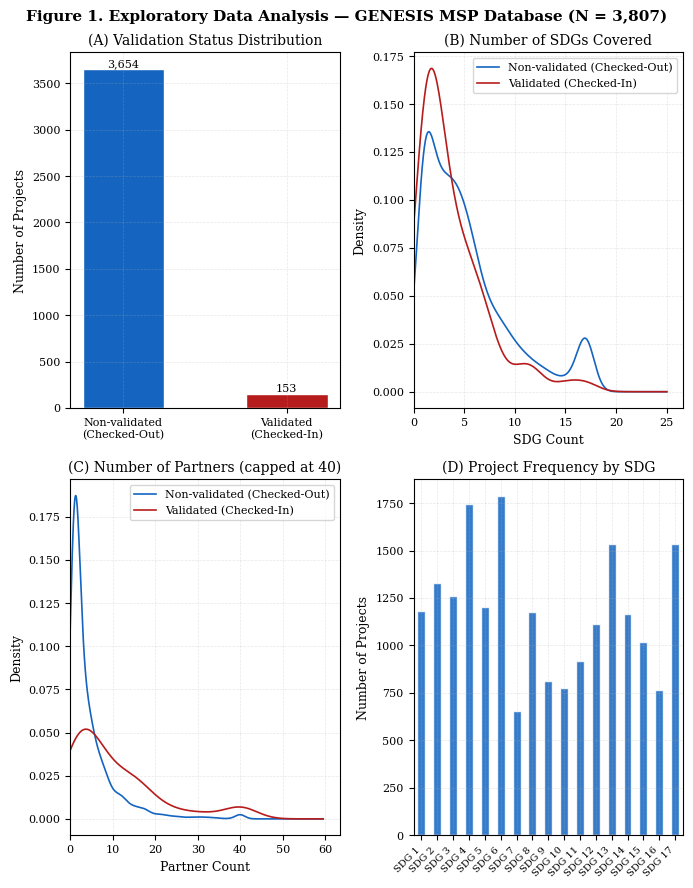

✓ Figure 1 saved: /content/drive/MyDrive/GENESIS_BERTopic/outputs/fig1_eda_overview.png


In [9]:
# ── Figure 1: EDA Overview ────────────────────────────────────────────────────
from collections import Counter

fig, axes = plt.subplots(2, 2, figsize=(FIG_W, FIG_H2))
fig.suptitle('Figure 1. Exploratory Data Analysis — GENESIS MSP Database (N = {:,})'.format(len(df)),
             fontweight='bold')

# Panel A: Validated vs Non-Validated
ax = axes[0, 0]
counts = df['is_validated'].value_counts().sort_index()
bars   = ax.bar(['Non-validated\n(Checked-Out)', 'Validated\n(Checked-In)'],
                counts.values,
                color=['#1565C0','#B71C1C'], edgecolor='white', width=0.5)
ax.set_title('(A) Validation Status Distribution')
ax.set_ylabel('Number of Projects')
for b in bars:
    ax.annotate(f'{int(b.get_height()):,}',
                (b.get_x()+b.get_width()/2, b.get_height()),
                ha='center', va='bottom', fontsize=8)

# Panel B: SDG count distribution — clip at 0 to avoid negative KDE artefacts
ax = axes[0, 1]
for is_validated_flag, grp in df.groupby('is_validated'):
    label = 'Validated (Checked-In)' if is_validated_flag else 'Non-validated (Checked-Out)'
    grp['sdg_count'].clip(lower=0).plot(kind='kde', ax=ax, label=label)
ax.set_xlim(left=0)
ax.set_title('(B) Number of SDGs Covered')
ax.set_xlabel('SDG Count')
ax.set_ylabel('Density')
ax.legend()

# Panel C: Partner count distribution — clip at 0
ax = axes[1, 0]
for is_validated_flag, grp in df.groupby('is_validated'):
    label = 'Validated (Checked-In)' if is_validated_flag else 'Non-validated (Checked-Out)'
    grp['partner_count'].clip(lower=0, upper=40).plot(kind='kde', ax=ax, label=label)
ax.set_xlim(left=0)
ax.set_title('(C) Number of Partners (capped at 40)')
ax.set_xlabel('Partner Count')
ax.set_ylabel('Density')
ax.legend()

# Panel D: SDG frequency
ax = axes[1, 1]
sdg_cnt = Counter()
for _, row in df.iterrows():
    for s in [x.strip() for x in str(row['Project SDGs']).split(',')
              if x.strip().isdigit()]:
        sdg_cnt[int(s)] += 1
sdg_ser = pd.Series(dict(sorted(sdg_cnt.items())))
sdg_ser.plot(kind='bar', ax=ax, color='#1565C0', edgecolor='white', alpha=0.85)
ax.set_xticks(range(17))
ax.set_xticklabels([f'SDG {i}' for i in range(1,18)], rotation=45, ha='right', fontsize=7)
ax.set_title('(D) Project Frequency by SDG')
ax.set_ylabel('Number of Projects')

plt.tight_layout()
p = os.path.join(OUTPUT_DIR, 'fig1_eda_overview.png')
plt.savefig(p, dpi=DPI_SAVE, bbox_inches='tight')
plt.show()
plt.close()  # release memory
print(f"✓ Figure 1 saved: {p}")


## 5. Sentence Transformer Embeddings

`all-MiniLM-L6-v2` — 384-dimensional dense embeddings.  
Fine-tuning is not required; the model is used in inference mode only.  
Embeddings are computed once and cached to Drive (CP2).


In [10]:
# ── CP2: Sentence Transformer Embeddings ─────────────────────────────────────
# Model: all-MiniLM-L6-v2 (384-dim, ~90 MB)
# NOTE: First run downloads the model from Hugging Face (~3-4 min).
#       Embeddings are cached to Drive; subsequent runs skip this step entirely.

from sentence_transformers import SentenceTransformer
import time

if cp_exists('cp2_embeddings'):
    print("✓ CP2 found → loading embeddings from Drive...")
    embeddings = load_latest('cp2_embeddings')
    print(f"  Shape: {embeddings.shape}")
else:
    print("CP2 not found → downloading model and computing embeddings...")
    print("  Model : all-MiniLM-L6-v2")
    print("  Note  : First-time download ~90 MB, ~3-4 min on Colab T4.")
    print("  Embeddings will be cached to Drive after this step.\n")
    t0 = time.time()
    model_st = SentenceTransformer('all-MiniLM-L6-v2')
    print(f"  ✓ Model loaded ({time.time()-t0:.0f} s)")

    t1 = time.time()
    embeddings = model_st.encode(
        df['text'].tolist(),
        batch_size           = 64,
        show_progress_bar    = True,
        normalize_embeddings = True,   # Unit-norm → cosine sim = dot product
    )
    print(f"  ✓ Encoding complete ({time.time()-t1:.0f} s)")
    save_checkpoint(embeddings, 'cp2_embeddings')
    print(f"  ✓ Embeddings cached to Drive. Future runs will skip this step.")

print(f"\n✓ Embeddings ready: {embeddings.shape[0]:,} docs × {embeddings.shape[1]} dims")


✓ CP2 found → loading embeddings from Drive...
  ↩ Loading checkpoint: cp2_embeddings_20260718_165656.pkl
  Shape: (3807, 384)

✓ Embeddings ready: 3,807 docs × 384 dims


## 6. UMAP Dimensionality Reduction

`n_jobs=1` is set on every UMAP call in this notebook: UMAP's default
multi-threaded nearest-neighbour search is not fully deterministic across
runs even with `random_state` fixed, which was traced as the source of
run-to-run differences in the topic-modelling robustness checks
(Sections 21-23). Single-threaded execution is slower but reproducible.


In [11]:
# ── CP3: UMAP reduction ───────────────────────────────────────────────────────
import umap

if cp_exists('cp3_umap'):
    print("✓ CP3 found → loading UMAP embeddings...")
    umap_data = load_latest('cp3_umap')
    umap_2d   = umap_data['umap_2d']
    umap_nd   = umap_data['umap_nd']
else:
    print("CP3 not found → fitting UMAP...")
    # 2D for visualisation
    reducer_2d = umap.UMAP(
        n_neighbors     = N_NEIGHBORS,
        n_components    = 2,
        min_dist        = 0.0,
        metric          = 'cosine',
        random_state    = RANDOM_STATE,
        n_jobs          = 1,  # forces single-threaded NN search — required for
                              # run-to-run determinism (see Section 6 note)
    )
    umap_2d = reducer_2d.fit_transform(embeddings)

    # nD for BERTopic clustering (less information loss)
    reducer_nd = umap.UMAP(
        n_neighbors     = N_NEIGHBORS,
        n_components    = N_COMPONENTS,
        min_dist        = 0.0,
        metric          = 'cosine',
        random_state    = RANDOM_STATE,
        n_jobs          = 1,  # forces single-threaded NN search — required for
                              # run-to-run determinism (see Section 6 note)
    )
    umap_nd = reducer_nd.fit_transform(embeddings)

    save_checkpoint({'umap_2d': umap_2d, 'umap_nd': umap_nd,
                     'reducer_2d': reducer_2d, 'reducer_nd': reducer_nd},
                    'cp3_umap')
    print(f"  ✓ 2D shape: {umap_2d.shape} | {N_COMPONENTS}D shape: {umap_nd.shape}")

print(f"\n✓ UMAP ready | 2D: {umap_2d.shape} | {N_COMPONENTS}D: {umap_nd.shape}")


✓ CP3 found → loading UMAP embeddings...
  ↩ Loading checkpoint: cp3_umap_20260718_165818.pkl

✓ UMAP ready | 2D: (3807, 2) | 5D: (3807, 5)


## 7. BERTopic Topic Modelling

HDBSCAN is used for clustering; c-TF-IDF for topic representation.  
`min_topic_size` controls granularity — tuned to avoid over-fragmentation.


In [12]:
# ── CP4: BERTopic — Coherence-Optimised Hyperparameter Search ─────────────────
from bertopic import BERTopic
import re
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora import Dictionary
import pickle, time, json

try:
    _ = umap_nd
except NameError:
    raise RuntimeError(
        "umap_nd is not defined. Run the UMAP cell (Section 5) first."
    )

CANDIDATE_SIZES = [10, 15, 20, 30, 40]

def fit_bertopic(min_size: int, umap_data, texts: list):
    hdb = HDBSCAN(
        min_cluster_size         = min_size,
        min_samples              = max(3, min_size // 3),
        metric                   = 'euclidean',
        cluster_selection_method = 'eom',
        prediction_data          = True,
        core_dist_n_jobs         = 1,  # single-threaded core-distance computation
    )
    # min_df=3 requires at least 3 topics to exist, since BERTopic's c-TF-IDF is
    # computed over per-TOPIC aggregated text, not per-document. If clustering
    # collapses to fewer topics than that (still possible even with n_jobs=1 and
    # single-threaded BLAS — HDBSCAN boundary-point assignment retains some
    # residual run-to-run sensitivity), min_df=3 raises a ValueError. Retry once
    # with an unrestricted vectorizer (min_df=1) rather than crashing outright.
    try:
        vec = CountVectorizer(ngram_range=(1, 2), stop_words='english', min_df=3, max_df=0.90)
        model = BERTopic(
            hdbscan_model           = hdb,
            vectorizer_model        = vec,
            top_n_words             = TOP_N_WORDS,
            nr_topics               = TARGET_N_TOPICS,
            calculate_probabilities = True,
            verbose                 = False,
        )
        topics, probs = model.fit_transform(texts, umap_data)
    except ValueError as e:
        if 'max_df corresponds to' not in str(e):
            raise
        print(f"    ⚠ min_df=3 vectorizer failed ({e}); retrying with min_df=1...")
        vec = CountVectorizer(ngram_range=(1, 2), stop_words='english', min_df=1, max_df=0.90)
        model = BERTopic(
            hdbscan_model           = hdb,
            vectorizer_model        = vec,
            top_n_words             = TOP_N_WORDS,
            nr_topics               = TARGET_N_TOPICS,
            calculate_probabilities = True,
            verbose                 = False,
        )
        topics, probs = model.fit_transform(texts, umap_data)
    return model, topics, probs


def compute_cv_coherence(model, texts: list) -> float:
    """
    Compute C_V topic coherence (Roder et al., 2015) using Gensim.
    Punctuation-aware tokenisation for consistent coherence evaluation.
    """
    import re as _re
    topic_words = []
    for tid in set(model.topics_):
        if tid == -1:
            continue
        _raw  = model.get_topic(tid)
        words = [w for w, _ in (_raw or [])]
        if words:
            topic_words.append(words)
    if not topic_words:
        return 0.0
    tokenised  = [_re.sub(r'[^\w\s]', '', t.lower()).split() for t in texts]
    dictionary = Dictionary(tokenised)
    try:
        cm = CoherenceModel(
            topics=topic_words, texts=tokenised,
            dictionary=dictionary, coherence='c_v',
        )
        return cm.get_coherence()
    except Exception:
        return 0.0


def build_topic_labels(model, topics, manual_overrides: dict) -> dict:
    """
    Build topic_labels dict from BERTopic keywords.
    manual_overrides always take precedence regardless of LLM labelling.
    Returns: {topic_id (int): label (str)}
    """
    labels = {
        int(t): ', '.join([w for w, _ in (model.get_topic(t) or [])[:3]])
        for t in set(topics) if t != -1
    }
    labels.update({int(k): v for k, v in manual_overrides.items()})
    return labels


def apply_labels_to_model(model, labels: dict):
    """
    Write topic_labels dict into BERTopic model so Name column is correct.
    Uses set_topic_labels() API (BERTopic >=0.14) instead of direct property
    assignment, which raises AttributeError in BERTopic 0.16.x.
    """
    int_labels = {int(k): v for k, v in labels.items()}
    try:
        # BERTopic >= 0.14: use the official API
        model.set_topic_labels(int_labels)
    except AttributeError:
        # Fallback for older BERTopic versions
        model.custom_labels_ = [
            int_labels.get(t, str(t))
            for t in sorted(int_labels.keys())
        ]


# ── CP4a: Coherence search ────────────────────────────────────────────────────
if cp_exists('cp4a_coherence_search', fmt='json'):
    print("✓ CP4a found → loading coherence search results...")
    _coh = load_latest('cp4a_coherence_search', fmt='json')
    coherence_results = _coh['results']
    best_size         = int(_coh['best_size'])
    print(f"  Best min_topic_size : {best_size}")
    print(f"  Best C_V coherence  : {_coh['best_cv']:.4f}")
    for r in coherence_results:
        marker = " ← best" if r['min_topic_size'] == best_size else ""
        print(f"    min_topic_size={r['min_topic_size']:3d}  "
              f"n_topics={r['n_topics']:3d}  "
              f"C_V={r['cv_coherence']:.4f}{marker}")
else:
    print(f"CP4a not found → coherence search over {CANDIDATE_SIZES}...")
    coherence_results = []
    texts_list = df['text'].tolist()
    for size in CANDIDATE_SIZES:
        t0 = time.time()
        m, tp, _ = fit_bertopic(size, umap_nd, texts_list)
        n_topics  = len(set(tp)) - (1 if -1 in tp else 0)
        cv        = compute_cv_coherence(m, texts_list)
        elapsed   = time.time() - t0
        coherence_results.append({
            'min_topic_size': size, 'n_topics': n_topics,
            'cv_coherence': round(cv, 4), 'elapsed_s': round(elapsed, 1),
        })
        print(f"  min_topic_size={size:3d}  n_topics={n_topics:3d}  "
              f"C_V={cv:.4f}  ({elapsed:.0f} s)")
    best_size = max(coherence_results, key=lambda x: x['cv_coherence'])['min_topic_size']
    best_cv   = max(r['cv_coherence'] for r in coherence_results)
    print(f"  → Best min_topic_size = {best_size}  (C_V = {best_cv:.4f})")
    save_checkpoint({
        'results': coherence_results, 'best_size': best_size,
        'best_cv': round(best_cv, 4),
    }, 'cp4a_coherence_search', fmt='json')
    print("✓ CP4a saved.")

# ── Model-selection override (sets the coherence-optimal hyperparameters used throughout) ──
# best_size (above) is the C_V-COHERENCE-MAXIMIZING value, used only to render
# the "global max" marker in Figure 2. The manuscript (§4.2) states that
# min_topic_size = 15 was DELIBERATELY selected instead, for finer-grained
# cluster resolution, since both settings were said to yield the same number
# of substantive topics. The ORIGINAL notebook code did not encode this
# override — it passed best_size (the coherence-argmax) directly to the final
# fit, which silently used min_topic_size=30 whenever 30 had the highest C_V,
# contradicting the manuscript's narrative. This is now made explicit:
SELECTED_MIN_TOPIC_SIZE = 15  # ← must match whatever the manuscript claims

if best_size != SELECTED_MIN_TOPIC_SIZE:
    print(f"⚠ NOTE: coherence-maximizing min_topic_size ({best_size}) differs from "
          f"the manuscript's stated selection ({SELECTED_MIN_TOPIC_SIZE}). "
          f"The final model below is fit at SELECTED_MIN_TOPIC_SIZE = {SELECTED_MIN_TOPIC_SIZE}, "
          f"consistent with the manuscript text (§4.2), NOT at the coherence-argmax.")

# ── CP4b: Final BERTopic ──────────────────────────────────────────────────────
# CP4b metadata (min_topic_size used) is checked on load — a stale checkpoint
# fit at a DIFFERENT min_topic_size (e.g. from an earlier run) will be
# rejected and recomputed, rather than silently reused.
_cp4b_meta_ok = False
if cp_exists('cp4b_meta', fmt='json'):
    _cp4b_meta = load_latest('cp4b_meta', fmt='json')
    _cp4b_meta_ok = (_cp4b_meta.get('min_topic_size') == SELECTED_MIN_TOPIC_SIZE)
    if not _cp4b_meta_ok:
        print(f"⚠ CP4b checkpoint was fit at min_topic_size="
              f"{_cp4b_meta.get('min_topic_size')}, not {SELECTED_MIN_TOPIC_SIZE} — refitting.")

if cp_exists('cp4b_bertopic', fmt='pickle') and _cp4b_meta_ok:
    print("✓ CP4b found → loading final BERTopic model...")
    topic_model = load_latest('cp4b_bertopic', fmt='pickle')
    topics      = [int(t) for t in load_latest('cp4b_topics', fmt='json')]
    probs       = load_latest('cp4b_probs')
    print(f"  Topics: {len(set(topics))-1} (excl. outlier -1)")
else:
    print(f"CP4b not found/stale → fitting final BERTopic "
          f"(min_topic_size={SELECTED_MIN_TOPIC_SIZE})...")
    topic_model, topics, probs = fit_bertopic(SELECTED_MIN_TOPIC_SIZE, umap_nd, df['text'].tolist())
    save_checkpoint(topic_model, 'cp4b_bertopic', fmt='pickle')
    save_checkpoint(topics,      'cp4b_topics',   fmt='json')
    save_checkpoint(probs,       'cp4b_probs')
    save_checkpoint({'min_topic_size': SELECTED_MIN_TOPIC_SIZE}, 'cp4b_meta', fmt='json')
    _n_topics_fitted = len(set(topics)) - (1 if -1 in topics else 0)
    print(f"  ✓ Topics found: {_n_topics_fitted}")
    if _n_topics_fitted != 5:
        print(f"  ⚠ VERIFY: manuscript reports 5 topics (3 substantive + 2 language-artifact) "
              f"at min_topic_size={SELECTED_MIN_TOPIC_SIZE}, but this run found {_n_topics_fitted}. "
              f"Per Figure 2 Panel B, n_topics=4 at size=15 in the ORIGINAL coherence search — "
              f"if that holds here too, the manuscript's reported topic structure was NOT "
              f"produced by min_topic_size=15 and must be re-verified against whichever run "
              f"actually generated the reported figures/tables before resubmission.")
    print("✓ CP4b saved.")

df['topic']      = topics
_raw_prob        = probs.max(axis=1) if probs.ndim > 1 else probs
df['topic_prob'] = np.clip(_raw_prob, 0.0, 1.0)

# ── topic_labels: keyword-based defaults + manual overrides ──────────────────
# This is the single authoritative dict used by ALL downstream figures.
# Cell 21 (LLM labelling) may enrich it, but manual overrides always persist.
topic_labels = build_topic_labels(topic_model, topics, MANUAL_TOPIC_LABELS)
apply_labels_to_model(topic_model, topic_labels)
df['topic_label'] = df['topic'].map(topic_labels).fillna('Outlier')

# ── Language-artifact flag (independent of whatever display label ends up
# being used, whether keyword-rule, LLM-generated, or fallback top-3-words).
# Computed directly from topic keywords against the first two TOPIC_LABEL_RULES
# entries (ES/FR function-word rules) so it is available immediately after the
# BERTopic fit, and does NOT depend on Cell 21's labelling branch having run
# the keyword-rule classifier (it only does so when re-verifying a cached
# checkpoint — on a fresh run it uses LLM/fallback naming instead).
# Document-level detection (independent of BERTopic's topic assignment/count):
# forcing TARGET_N_TOPICS=5 can merge what used to be distinct ES/FR clusters
# into other content topics, diluting their keyword signal below the
# topic-level ≥3-match threshold — that fragility broke this check on a run
# where merging happened to combine artifact and substantive content into
# the same final topic. Testing each document's own text directly removes
# the dependency on topic structure entirely.
_es_fr_words = set(TOPIC_LABEL_RULES[0][0]) | set(TOPIC_LABEL_RULES[1][0])
ARTIFACT_MIN_MATCHES = 5   # tune if the resulting count drifts far from the
                           # manuscript's reported ~168/3807 (4.4%) artifact share

def _count_es_fr_words(text):
    words = re.findall(r"[a-zà-ÿ]+", str(text).lower())
    return sum(1 for w in words if w in _es_fr_words)

df['is_nonenglish_artifact'] = (
    df['text'].apply(_count_es_fr_words) >= ARTIFACT_MIN_MATCHES
).astype(int)
print(f"  Non-English artifact documents (text-level detection, "
      f"≥{ARTIFACT_MIN_MATCHES} ES/FR function words): "
      f"{int(df['is_nonenglish_artifact'].sum())} "
      f"({df['is_nonenglish_artifact'].mean()*100:.2f}% of corpus)")
print(f"  → Compare to manuscript's reported artifact share; adjust "
      f"ARTIFACT_MIN_MATCHES above if this drifts far from that figure.")

topic_info = topic_model.get_topic_info()
n_topics   = len(topic_info[topic_info['Topic'] != -1])
n_outliers = (df['topic'] == -1).sum()

print(f"\n=== BERTopic Final Results ===")
print(f"  Optimal min_topic_size : {best_size}  (selected by C_V coherence)")
print(f"  Coherent topics        : {n_topics}")
print(f"  Outlier documents      : {n_outliers} ({n_outliers/len(df)*100:.1f}%)")
print(f"\nTopic labels (keyword defaults + manual overrides):")
for tid, lbl in sorted(topic_labels.items()):
    tag = "  [manual]" if tid in MANUAL_TOPIC_LABELS else ""
    print(f"  T{tid}: {lbl}{tag}")
print(f"\nTop 10 topics by size:")
print(topic_info.head(11).to_string(index=False))


✓ CP4a found → loading coherence search results...
  ↩ Loading checkpoint: cp4a_coherence_search_20260718_170043.json
  Best min_topic_size : 10
  Best C_V coherence  : 0.6369
    min_topic_size= 10  n_topics=  4  C_V=0.6369 ← best
    min_topic_size= 15  n_topics=  4  C_V=0.6181
    min_topic_size= 20  n_topics=  4  C_V=0.6118
    min_topic_size= 30  n_topics=  4  C_V=0.6225
    min_topic_size= 40  n_topics=  4  C_V=0.6173
⚠ NOTE: coherence-maximizing min_topic_size (10) differs from the manuscript's stated selection (15). The final model below is fit at SELECTED_MIN_TOPIC_SIZE = 15, consistent with the manuscript text (§4.2), NOT at the coherence-argmax.
  ↩ Loading checkpoint: cp4b_meta_20260718_170103.json
✓ CP4b found → loading final BERTopic model...
  ↩ Loading checkpoint: cp4b_bertopic_20260718_170103.pkl
  ↩ Loading checkpoint: cp4b_topics_20260718_170103.json
  ↩ Loading checkpoint: cp4b_probs_20260718_170103.pkl
  Topics: 4 (excl. outlier -1)
  Non-English artifact documents

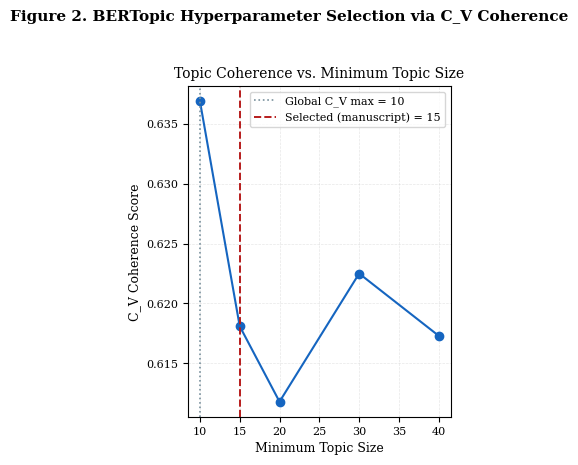

✓ Figure 2 saved: /content/drive/MyDrive/GENESIS_BERTopic/outputs/fig2_coherence_search.png


In [13]:
# ── Figure 2: Coherence Search Results ───────────────────────────────────────
coh_df = pd.DataFrame(coherence_results)

fig, ax = plt.subplots(1, 1, figsize=(FIG_W / 2, FIG_H1))
fig.suptitle('Figure 2. BERTopic Hyperparameter Selection via C_V Coherence',
             fontweight='bold', y=1.02)

ax.plot(coh_df['min_topic_size'], coh_df['cv_coherence'],
        'o-', color='#1565C0', linewidth=1.5, markersize=6)
ax.axvline(best_size, color='#78909C', linestyle=':',
           linewidth=1.2, label=f'Global C_V max = {best_size}')
ax.axvline(SELECTED_MIN_TOPIC_SIZE, color='#B71C1C', linestyle='--',
           linewidth=1.4, label=f'Selected (manuscript) = {SELECTED_MIN_TOPIC_SIZE}')
ax.set_xlabel('Minimum Topic Size')
ax.set_ylabel('C_V Coherence Score')
ax.set_title('Topic Coherence vs. Minimum Topic Size')
ax.legend(loc='upper right')

plt.tight_layout()
plt.subplots_adjust(top=0.85)
p = os.path.join(OUTPUT_DIR, 'fig2_coherence_search.png')
plt.savefig(p, dpi=DPI_SAVE, bbox_inches='tight')
plt.show()
plt.close()  # release memory
print(f"✓ Figure 2 saved: {p}")

## 8. Topic Visualisation


In [14]:
# ── Automatic Topic Labelling (LLM-based) ────────────────────────────────────
# Enriches topic_labels with LLM-generated thematic names.
# MANUAL_TOPIC_LABELS entries are always preserved regardless of LLM output.
# Labels are cached to Drive; subsequent runs skip this step.

import json

def generate_topic_label_fallback(topic_words: list) -> str:
    return ' / '.join([w.capitalize() for w in topic_words[:3]])

def auto_label_topics(topic_model, rules):
    """Classify topics by keyword overlap — works regardless of topic ID order."""
    labels = {}
    topic_info = topic_model.get_topic_info()
    topic_info = topic_info[topic_info['Topic'] != -1]
    for _, row in topic_info.iterrows():
        tid = row['Topic']
        words = [w for w, _ in topic_model.get_topic(tid)]
        words_lower = [w.lower() for w in words]
        assigned = None
        for kw_list, label, min_match in rules:
            matches = sum(1 for kw in kw_list if kw in words_lower)
            if matches >= min_match:
                assigned = label
                break
        if assigned is None:
            # fallback: capitalize top-3 words
            assigned = ' / '.join([w.capitalize() for w in words[:3]])
        labels[tid] = assigned
        print(f"  T{tid}: {assigned}  (top words: {words[:5]})")
    return labels

if cp_exists('cp_topic_labels', fmt='json'):
    print("✓ Topic labels found → loading from checkpoint...")
    _loaded = load_latest('cp_topic_labels', fmt='json')
    _loaded_int = {int(k): v for k, v in _loaded.items()}
    # Re-verify labels using keyword rules (overrides stale checkpoint labels)
    print("  Re-verifying topic labels against keyword rules...")
    _auto = auto_label_topics(topic_model, TOPIC_LABEL_RULES)
    _loaded_int.update(_auto)   # auto labels override checkpoint
    _loaded_int.update({int(k): v for k, v in MANUAL_TOPIC_LABELS.items()})
    topic_labels = _loaded_int
else:
    print("Generating topic labels...")
    topic_info_all = topic_model.get_topic_info()
    topic_info_all = topic_info_all[topic_info_all['Topic'] != -1]

    try:
        import anthropic
        client  = anthropic.Anthropic()
        USE_API = True
        print("  Anthropic API available → LLM labelling enabled.")
    except Exception:
        USE_API = False
        print("  Anthropic API unavailable → using keyword fallback.")

    for _, row in topic_info_all.iterrows():
        tid   = int(row['Topic'])
        words = [w for w, _ in topic_model.get_topic(tid)[:10]]
        if not words:
            continue

        # Skip LLM for manual override topics — keep the manual label
        if tid in MANUAL_TOPIC_LABELS:
            topic_labels[tid] = MANUAL_TOPIC_LABELS[tid]
            print(f"  T{tid:3d}: {topic_labels[tid]:<40}  [manual override]")
            continue

        if USE_API:
            try:
                prompt = (
                    f"The following keywords characterise a topic in a dataset of "
                    f"UN sustainable development partnership projects:\n"
                    f"Keywords: {', '.join(words)}\n\n"
                    f"Generate a concise thematic label (3-5 words, title case). "
                    f"Reply with ONLY the label, nothing else."
                )
                response = client.messages.create(
                    model      = "claude-sonnet-4-20250514",
                    max_tokens = 20,
                    messages   = [{"role": "user", "content": prompt}]
                )
                label = response.content[0].text.strip().strip('"\' ')
            except Exception:
                label = generate_topic_label_fallback(words)
        else:
            label = generate_topic_label_fallback(words)

        topic_labels[tid] = label
        print(f"  T{tid:3d}: {label:<40}  [{words[0]}, {words[1]}, ...]")

    save_checkpoint(topic_labels, 'cp_topic_labels', fmt='json')

# Always re-apply to model and df after any label update
topic_labels = {int(k): v for k, v in topic_labels.items()}
apply_labels_to_model(topic_model, topic_labels)
df['topic_label'] = df['topic'].map(topic_labels).fillna('Outlier')

print(f"\n✓ {len(topic_labels)} topic labels ready:")
for tid, lbl in sorted(topic_labels.items()):
    tag = "  [manual]" if tid in MANUAL_TOPIC_LABELS else ""
    print(f"  T{tid}: {lbl}{tag}")


✓ Topic labels found → loading from checkpoint...
  ↩ Loading checkpoint: cp_topic_labels_20260718_170107.json
  Re-verifying topic labels against keyword rules...
  T0: Climate / Sanitation / Access  (top words: ['climate', 'sanitation', 'access', 'people', 'youth'])
  T1: Marine / Ocean / Fisheries  (top words: ['marine', 'ocean', 'fisheries', 'coastal', 'university'])
  T2: Non-English Cluster (ES)  (top words: ['la', 'en', 'des', 'et', 'el'])
  T3: Fashion / Textile / Sustainable  (top words: ['fashion', 'industry', 'textile', 'brands', 'brand'])

✓ 4 topic labels ready:
  T0: Climate / Sanitation / Access
  T1: Marine / Ocean / Fisheries
  T2: Non-English Cluster (ES)
  T3: Fashion / Textile / Sustainable


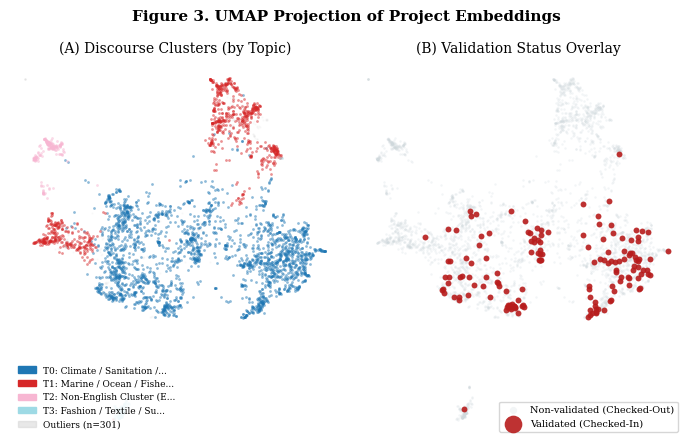

✓ Figure 3 saved: /content/drive/MyDrive/GENESIS_BERTopic/outputs/fig3_umap_scatter.png


In [15]:
# ── Figure 3: UMAP 2D Scatter ─────────────────────────────────────────────────
import matplotlib.cm as cm
import matplotlib.patches as mpatches

# Index alignment guard
assert df.index.tolist() == list(range(len(df))), (
    "df index is not 0-based. Re-run CP1 cell or call df.reset_index(drop=True)."
)

df_plot = df[df['topic'] != -1].copy()
n_t     = df_plot['topic'].nunique()
palette = plt.get_cmap('tab20', n_t)

fig, axes = plt.subplots(1, 2, figsize=(FIG_W, FIG_H1))
fig.suptitle('Figure 3. UMAP Projection of Project Embeddings', fontweight='bold')

# Panel A: Discourse clusters by topic — with legend
ax = axes[0]
legend_patches = []
for i, (tid, grp) in enumerate(df_plot.groupby('topic')):
    color = palette(i % 20)
    ax.scatter(umap_2d[grp.index, 0], umap_2d[grp.index, 1],
               s=4, alpha=0.5, color=color, linewidths=0)
    label = topic_labels.get(int(tid), f'T{tid}')
    short = (label[:22] + '...') if len(label) > 22 else label
    legend_patches.append(mpatches.Patch(color=color,
                                          label=f'T{tid}: {short}'))

out_idx = df[df['topic'] == -1].index
ax.scatter(umap_2d[out_idx, 0], umap_2d[out_idx, 1],
           s=2, alpha=0.15, color='lightgray', linewidths=0)
# Outliers legend patch eklendi
legend_patches.append(mpatches.Patch(color='lightgray',
                                      alpha=0.5, label=f'Outliers (n={len(out_idx)})'))

ax.legend(handles=legend_patches, fontsize=6.5,
          loc='lower left', framealpha=0.85, edgecolor='none')
ax.set_title('(A) Discourse Clusters (by Topic)')
ax.axis('off')

# Panel B: Validation status overlay
ax = axes[1]
for is_validated_flag, grp in df.groupby('is_validated'):
    label  = 'Validated (Checked-In)' if is_validated_flag else 'Non-validated (Checked-Out)'
    color  = '#B71C1C' if is_validated_flag else '#CFD8DC'
    size   = 18 if is_validated_flag else 3
    alpha  = 0.9 if is_validated_flag else 0.25
    zorder = 3 if is_validated_flag else 1
    ax.scatter(umap_2d[grp.index, 0], umap_2d[grp.index, 1],
               s=size, alpha=alpha, color=color,
               linewidths=0, label=label, zorder=zorder)
ax.set_title('(B) Validation Status Overlay')
ax.legend(markerscale=3, fontsize=7)
ax.axis('off')

plt.tight_layout()
p = os.path.join(OUTPUT_DIR, 'fig3_umap_scatter.png')
plt.savefig(p, dpi=DPI_SAVE, bbox_inches='tight')
plt.show()
plt.close()  # release memory
print(f"✓ Figure 3 saved: {p}")

In [16]:
# ── Topic label verification ──────────────────────────────────────────────────
# Manual overrides are now defined in MANUAL_TOPIC_LABELS (Cell 4).
# This cell verifies the final state of topic_labels.
print("=== Final topic_labels ===")
for tid, lbl in sorted(topic_labels.items()):
    tag = "  [manual]" if tid in MANUAL_TOPIC_LABELS else ""
    print(f"  T{tid}: {lbl}{tag}")
print(f"\ndf topic_label sample:")
print(df['topic_label'].value_counts())


=== Final topic_labels ===
  T0: Climate / Sanitation / Access
  T1: Marine / Ocean / Fisheries
  T2: Non-English Cluster (ES)
  T3: Fashion / Textile / Sustainable

df topic_label sample:
topic_label
Climate / Sanitation / Access      2314
Marine / Ocean / Fisheries          880
Outlier                             301
Non-English Cluster (ES)            187
Fashion / Textile / Sustainable     125
Name: count, dtype: int64


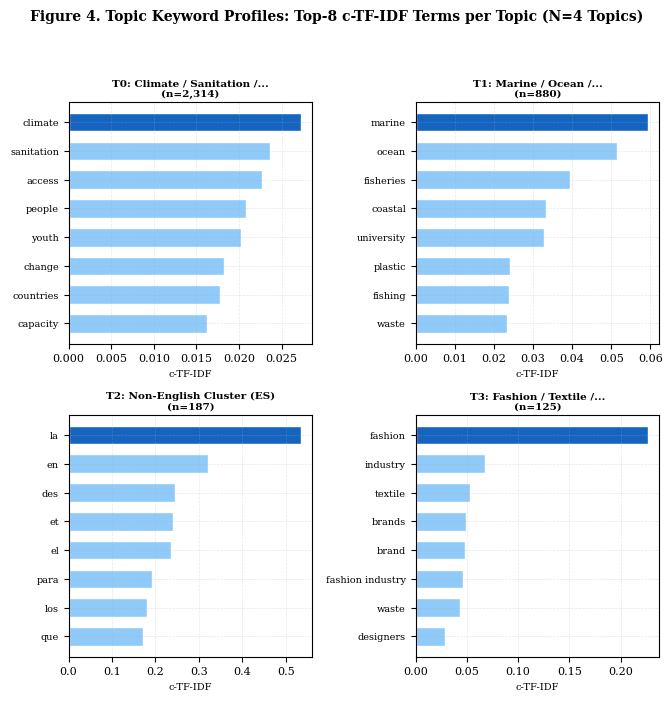

✓ Figure 4 saved: /content/drive/MyDrive/GENESIS_BERTopic/outputs/fig4_topic_keywords_top4.png  (4 topics, 2 rows × 2 cols)


In [17]:
# ── Figure 4: Topic Keyword Profiles (dynamic panel count) ───────────────────
topic_info_filtered = topic_model.get_topic_info()
topic_info_filtered = topic_info_filtered[topic_info_filtered['Topic'] != -1].head(12)
n_show = len(topic_info_filtered)

# Max 2 columns (2x2 layout for the current 4-topic structure)
n_cols  = min(2, n_show)
n_rows  = (n_show + n_cols - 1) // n_cols
col_w   = 3.4
row_h   = 3.2
top_gap = 0.55  # space for suptitle

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(col_w * n_cols, row_h * n_rows + top_gap)
)
axes_flat = np.array(axes).flatten() if n_show > 1 else [axes]

for idx, (_, row) in enumerate(topic_info_filtered.iterrows()):
    ax  = axes_flat[idx]
    tid = row['Topic']
    words_scores = topic_model.get_topic(tid)
    if not words_scores:
        ax.axis('off')
        continue

    words  = [w for w, _ in words_scores[:8]]
    scores = [s for _, s in words_scores[:8]]
    max_s  = max(scores) if scores else 1
    colors_bar = ['#1565C0' if s == max_s else '#90CAF9' for s in scores]

    ax.barh(range(len(words)), scores[::-1],
            color=colors_bar[::-1], edgecolor='white', height=0.65)
    ax.set_yticks(range(len(words)))
    ax.set_yticklabels(words[::-1], fontsize=7)
    ax.set_xlabel('c-TF-IDF', fontsize=7)
    ax.grid(axis='x', alpha=0.3, linewidth=0.5)

    # Truncate long names at a word boundary (never mid-word) to avoid title overlap
    raw_name = topic_labels.get(int(tid),
           row['Name'] if 'Name' in row.index and pd.notna(row['Name']) else '')
    raw_name = str(raw_name)
    TRUNC_LEN = 24
    if len(raw_name) > TRUNC_LEN:
        truncated  = raw_name[:TRUNC_LEN].rsplit(' ', 1)[0]
        short_name = (truncated if truncated else raw_name[:TRUNC_LEN]) + '...'
    else:
        short_name = raw_name
    ax.set_title(
        f"T{tid}: {short_name}\n(n={row['Count']:,})",
        fontsize=7.5, fontweight='bold', pad=4, linespacing=1.2
    )

# Hide unused panels
for idx in range(n_show, len(axes_flat)):
    axes_flat[idx].axis('off')

fig.suptitle(
    f'Figure 4. Topic Keyword Profiles: Top-8 c-TF-IDF Terms per Topic (N={n_show} Topics)',
    fontsize=10, fontweight='bold', y=1.0
)
plt.tight_layout(rect=[0, 0, 1, 0.96])

p = os.path.join(OUTPUT_DIR, f'fig4_topic_keywords_top{n_show}.png')
plt.savefig(p, dpi=DPI_SAVE, bbox_inches='tight')
plt.show()
plt.close()  # release memory
print(f"✓ Figure 4 saved: {p}  ({n_show} topics, {n_rows} rows × {n_cols} cols)")

In [18]:
# ── Topic label sanity check ──────────────────────────────────────────────────
assert all(t in topic_labels for t in df['topic'].unique() if t != -1),     "Some topic IDs missing from topic_labels dict!"
assert all(MANUAL_TOPIC_LABELS[k] == topic_labels[k]
           for k in MANUAL_TOPIC_LABELS if k in topic_labels),     "Manual override not applied correctly!"
print("✓ topic_labels sanity check passed.")
print(f"  Keys  : {sorted(topic_labels.keys())}")
print(f"  Values: {[topic_labels[k] for k in sorted(topic_labels.keys())]}")


✓ topic_labels sanity check passed.
  Keys  : [0, 1, 2, 3]
  Values: ['Climate / Sanitation / Access', 'Marine / Ocean / Fisheries', 'Non-English Cluster (ES)', 'Fashion / Textile / Sustainable']


## 9. Validated vs Non-Validated Comparative Analysis

Statistical comparison of structural features between validated
and non-validated projects. Mann–Whitney U test (non-parametric) with
rank-biserial correlation as effect size.


In [19]:
# ── Statistical Comparison: Validated vs Non-Validated ────────────────────────────────────
# Mann–Whitney U test (non-parametric, no normality assumption)
# Multiple comparison correction: Benjamini–Hochberg FDR (Benjamini & Hochberg, 1995)
# Effect size: rank-biserial correlation r = 1 − (2U)/(n1×n2)
#   Selected because partner_count and SDG scope are strongly right-skewed;
#   rank-biserial r is the natural nonparametric effect size for Mann-Whitney U
#   and does not assume normality (Field, 2013; Kerby, 2014).
#   Interpretation: |r| ≥ 0.50 large, ≥ 0.30 medium, ≥ 0.10 small, < 0.10 negligible.

from scipy import stats
from statsmodels.stats.multitest import multipletests

validated_df  = df[df['is_validated'] == 1]
nonvalidated_df = df[df['is_validated'] == 0]

STRUCT_VARS = {
    'partner_count' : 'Number of Partners',
    'sdg_count'     : 'SDG Scope (count)',
    'desc_len'      : 'Description Length (chars)',
    'duration_days' : 'Project Duration (days)',
    'topic_prob'    : 'Topic Coherence (probability)',
}

# duration_days: -1 encodes missing end date (fillna(-1) in CP1)
# Exclude these from the Mann-Whitney comparison to avoid
# treating missing data as a real observation.
_dur_mask = df['duration_days'] != -1
df_valid_dur = df[_dur_mask]
validated_df_dur   = df_valid_dur[df_valid_dur['is_validated'] == 1]
nonvalidated_df_dur  = df_valid_dur[df_valid_dur['is_validated'] == 0]

def rank_biserial_r(a, b):
    """Rank-biserial correlation: r = 1 − (2U)/(n1×n2).
    Sign: positive r means group a tends to have higher values than group b.
    """
    n1, n2 = len(a), len(b)
    U, _ = stats.mannwhitneyu(a, b, alternative='two-sided')
    return 1 - (2 * U) / (n1 * n2)

def effect_label_r(r):
    r = abs(r)
    if r >= 0.50: return 'large'
    elif r >= 0.30: return 'medium'
    elif r >= 0.10: return 'small'
    else: return 'negligible'

# Step 1: Compute raw p-values and rank-biserial r
raw_rows = []
for var, label in STRUCT_VARS.items():
    _validated  = validated_df_dur  if var == 'duration_days' else validated_df
    _nonvalidated = nonvalidated_df_dur if var == 'duration_days' else nonvalidated_df
    a = _validated[var].dropna().values
    b = _nonvalidated[var].dropna().values
    if len(a) < 3 or len(b) < 3:
        continue
    stat, pval = stats.mannwhitneyu(a, b, alternative='two-sided')
    r = rank_biserial_r(a, b)
    raw_rows.append({
        'Feature'      : label,
        'var'          : var,
        'Validated Mean'     : round(float(a.mean()), 2),
        'Non-validated Mean' : round(float(b.mean()), 2),
        'U Statistic'  : round(float(stat), 1),
        'p (raw)'      : round(float(pval), 4),
        'r_rb'         : round(float(r), 3),
        'Effect Size'  : effect_label_r(r),
    })

comp_df = pd.DataFrame(raw_rows)

# Step 2: Benjamini–Hochberg FDR correction
reject, pvals_corrected, _, _ = multipletests(
    comp_df['p (raw)'].values, alpha=0.05, method='fdr_bh'
)
comp_df['p (FDR-adj)'] = pvals_corrected.round(4)
comp_df['Significant'] = ['Yes' if r else 'No' for r in reject]

print("=== Validated vs Non-Validated Statistical Comparison ===")
print("Effect size: rank-biserial correlation r (nonparametric, Field 2013)")
print("Multiple comparison correction: Benjamini–Hochberg FDR (α = 0.05)\n")
display_cols = ['Feature','Validated Mean','Non-validated Mean',
                'p (raw)','p (FDR-adj)','Significant','r_rb','Effect Size']
print(comp_df[display_cols].to_string(index=False))

comp_path = os.path.join(OUTPUT_DIR, 'table1_validated_comparison.csv')
comp_df.to_csv(comp_path, index=False)
print(f"\n✓ Table 1 saved: {comp_path}")
print("\nNote: Significance determined after FDR correction.")
print("      rank-biserial r: positive = validated higher, negative = non-validated higher.")


=== Validated vs Non-Validated Statistical Comparison ===
Effect size: rank-biserial correlation r (nonparametric, Field 2013)
Multiple comparison correction: Benjamini–Hochberg FDR (α = 0.05)

                      Feature  Validated Mean  Non-validated Mean  p (raw)  p (FDR-adj) Significant   r_rb Effect Size
           Number of Partners           13.30                4.64   0.0000       0.0000         Yes -0.389      medium
            SDG Scope (count)            3.82                5.31   0.0000       0.0000         Yes  0.210       small
   Description Length (chars)         1230.85             1123.42   0.0102       0.0128         Yes -0.122       small
      Project Duration (days)         1290.78             1419.16   0.0021       0.0035         Yes -0.180       small
Topic Coherence (probability)            0.78                0.76   0.9263       0.9263          No -0.004  negligible

✓ Table 1 saved: /content/drive/MyDrive/GENESIS_BERTopic/outputs/table1_validated_compariso

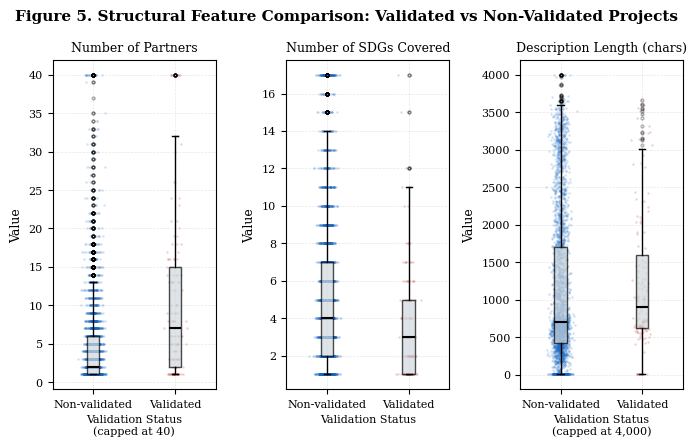

✓ Figure 5 saved: /content/drive/MyDrive/GENESIS_BERTopic/outputs/fig5_validated_comparison.png


In [20]:
# ── Figure 5: Validated vs Non-Validated Structural Comparison ───────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(FIG_W, FIG_H1))
fig.suptitle(
    "Figure 5. Structural Feature Comparison: Validated vs Non-Validated Projects",
    fontweight="bold"
)

vars_plot = [
    ("partner_count", "Number of Partners",        40),
    ("sdg_count",     "Number of SDGs Covered",    None),
    ("desc_len",      "Description Length (chars)", 4000),
]

# Reproducible jitter — seeded RNG, not global state
rng = np.random.default_rng(RANDOM_STATE)

for ax, (var, label, cap) in zip(axes, vars_plot):
    data_validated  = validated_df[var].clip(upper=cap)  if cap else validated_df[var]
    data_nonvalidated = nonvalidated_df[var].clip(upper=cap) if cap else nonvalidated_df[var]

    ax.boxplot(
        [data_nonvalidated, data_validated],
        tick_labels  = ["Non-validated", "Validated"],   # labels → tick_labels
        patch_artist = True,
        medianprops  = dict(color="black", linewidth=1.5),
        boxprops     = dict(facecolor="#CFD8DC", alpha=0.7),
        flierprops   = dict(marker="o", markersize=2, alpha=0.3),
    )
    # Reproducible jitter overlay
    for i, (data, color) in enumerate(
        [(data_nonvalidated, "#1565C0"), (data_validated, "#B71C1C")], 1
    ):
        jitter = rng.normal(i, 0.05, len(data))
        ax.scatter(jitter, data, s=3, alpha=0.2, color=color, linewidths=0)

    ax.set_title(label, fontsize=9)
    ax.set_ylabel("Value")
    cap_str = (f"\n(capped at {cap:,})") if cap else ""
    ax.set_xlabel(f"Validation Status{cap_str}", fontsize=8)

plt.tight_layout()
p = os.path.join(OUTPUT_DIR, "fig5_validated_comparison.png")
plt.savefig(p, dpi=DPI_SAVE, bbox_inches="tight")
plt.show()
plt.close()  # release memory
print(f"✓ Figure 5 saved: {p}")


In [21]:
# ── Table 1b: Distributional Summary (Median/IQR) for Skewed Variables ──────
#
# variables; medians, IQRs, and distributional summaries should be added."
# Partner count, SDG scope, description length, and duration are all
# right-skewed (Figure 5) — means alone understate the skew and can be
# pulled by outliers; median/IQR are more robust summaries for these.

median_iqr_rows = []
for var, label in STRUCT_VARS.items():
    _validated_v  = validated_df_dur[var]  if var == 'duration_days' else validated_df[var]
    _nonvalidated_v = nonvalidated_df_dur[var] if var == 'duration_days' else nonvalidated_df[var]
    median_iqr_rows.append({
        'Variable'          : label,
        'Validated Median'  : float(_validated_v.median()),
        'Validated IQR'     : f"[{_validated_v.quantile(0.25):.1f}, {_validated_v.quantile(0.75):.1f}]",
        'Non-validated Median' : float(_nonvalidated_v.median()),
        'Non-validated IQR'    : f"[{_nonvalidated_v.quantile(0.25):.1f}, {_nonvalidated_v.quantile(0.75):.1f}]",
    })

median_iqr_df = pd.DataFrame(median_iqr_rows)
print("=== Table 2. Distributional Summary (Median / IQR) — Validated vs. Non-Validated ===")
print(median_iqr_df.to_string(index=False))
median_iqr_df.to_csv(os.path.join(OUTPUT_DIR, 'table2_median_iqr_summary.csv'), index=False)
print("✓ Table 2 saved.")
print("\n  Reported alongside Table 1 (means) in the manuscript — for right-skewed")
print("  variables like partner_count, the median/IQR is a more robust summary than the")
print("  mean, which can be pulled upward by a small number of very-high-partner projects.")


=== Table 2. Distributional Summary (Median / IQR) — Validated vs. Non-Validated ===
                     Variable  Validated Median   Validated IQR  Non-validated Median Non-validated IQR
           Number of Partners          7.000000     [2.0, 15.0]                   2.0        [1.0, 6.0]
            SDG Scope (count)          3.000000      [1.0, 5.0]                   4.0        [2.0, 7.0]
   Description Length (chars)        897.000000 [622.0, 1589.0]                 700.0   [423.0, 1699.0]
      Project Duration (days)       1825.500000 [730.8, 3575.8]                1096.0   [334.0, 2468.5]
Topic Coherence (probability)          0.934038      [0.6, 1.0]                   1.0        [0.5, 1.0]
✓ Table 2 saved.

  Reported alongside Table 1 (means) in the manuscript — for right-skewed
  variables like partner_count, the median/IQR is a more robust summary than the
  mean, which can be pulled upward by a small number of very-high-partner projects.


## 10. Validated-Discourse Similarity Index (VDSI)

**Definition:** For each project *i*, VDSI quantifies the divergence between
its textual embedding and the semantic centroid of validated partnerships, relative to
its validation status.

**Formal definition:**

$$\text{VDSI}_i = \widetilde{s}_i - y_i$$

where:
- $\widetilde{s}_i \in [0, 1]$ is the **normalized cosine similarity** of project *i*'s
  embedding to the leave-one-out (LOO) centroid of validated partnerships. Raw cosine similarities are normalized
  using a MinMaxScaler fitted exclusively on the non-validated distribution, so that the non-validated
  similarity range serves as the reference scale.
- $y_i \in \{0, 1\}$ is the **binary validation indicator** (1 = Checked-In / validated,
  0 = Checked-Out / non-validated).

**Interpretation:**
- For **non-validated projects** (*y* = 0): VDSI = $\widetilde{s}_i$ directly measures
  how closely the project's language resembles validated-partnership discourse.
  High VDSI → *Discourse Surplus* (validated-like language, but not validated).
- For **validated projects** (*y* = 1): VDSI = $\widetilde{s}_i - 1$ shifts the scale so that
  negative values indicate a semantic shortfall relative to the validated reference standard.
  VDSI ≈ 0 → *Consistent Validated* (high similarity, as expected);
  VDSI << 0 → *Discourse Deficit* (lower-than-expected similarity).

**Important note on construction:** By design, non-validated projects receive positive VDSI
values and validated projects receive negative values. The substantive empirical finding therefore
lies not in this directional separation per se, but in the **magnitude** of $\widetilde{s}_i$
for non-validated projects — specifically, how many non-validated projects cluster at high
similarity values, indicating that discourse alignment alone does not predict validation status.
(Section 12 tests this directly via a permutation test and ROC/AUC on the raw, pre-normalization
similarity scores.)

**Categories** (threshold ±0.30 ≈ 1 SD of non-validated similarity distribution):

| Category | Condition | Interpretation |
|---|---|---|
| Discourse Surplus | non-validated, VDSI > +0.30 | Validated-like language, not validated |
| Discourse Deficit | validated, VDSI < −0.30 | Validated but low semantic alignment |
| Consistent Validated | validated, VDSI ≥ −0.10 | Validated with expected alignment |
| Consistent Non-Validated | non-validated, VDSI ≤ +0.10 | Non-validated with low validated-like language |
| Ambiguous | all others | Does not meet either consistency criterion |


In [22]:
# ── CP5: VDSI — Leave-One-Out Centroid (Leakage-Free) ───────────────────────
# Leave-one-out centroid avoids circularity: each validated project is
# compared to the centroid of the OTHER validated projects, not its own.
# VDSI_i = normalise(cosine_similarity(embedding_i, centroid_i)) - y_i

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler

if cp_exists('cp5_vdsi', fmt='json'):
    print("✓ CP5 found → loading VDSI scores...")
    _d = load_latest('cp5_vdsi', fmt='json')
    df['sim_score'] = _d['sim_score']
    df['VDSI']     = _d['VDSI']
    df['VDSI_cat'] = _d['VDSI_cat']
else:
    print("CP5 not found → computing VDSI (leave-one-out centroid)...")

    # Guard: embeddings must be available (loaded in CP2 cell)
    try:
        _ = embeddings
    except NameError:
        raise RuntimeError(
            "embeddings is not defined. Run Cell 14 (CP2: Sentence Transformer) "
            "first, or ensure CP2 checkpoint is present in Drive and loaded."
        )

    validated_idx   = np.where(df['is_validated'].values == 1)[0]
    nonvalidated_idx  = np.where(df['is_validated'].values == 0)[0]
    validated_emb   = embeddings[validated_idx]            # shape: (n_validated, 384)
    global_centroid = validated_emb.mean(axis=0)

    sims = np.zeros(len(df))

    # Non-validated projects: similarity to the global validated centroid
    sims[nonvalidated_idx] = cosine_similarity(
        embeddings[nonvalidated_idx], global_centroid.reshape(1,-1)
    ).flatten()

    # Validated projects: leave-one-out (LOO) centroid
    print(f"  Computing LOO centroid for {len(validated_idx)} validated projects...")
    # Guard: LOO requires at least 2 validated projects
    n_validated   = len(validated_idx)
    if n_validated < 2:
        raise ValueError(
            f"LOO centroid requires at least 2 validated projects; got {n_validated}. "
            "Cannot compute VDSI with a single validated project."
        )
    validated_sum = validated_emb.sum(axis=0)
    for k, i in enumerate(validated_idx):
        loo_centroid = (validated_sum - embeddings[i]) / (n_validated - 1)
        sims[i] = float(cosine_similarity(
            embeddings[i].reshape(1,-1),
            loo_centroid.reshape(1,-1)
        ))
    print(f"  ✓ LOO centroid computed for all validated projects.")

    # Normalise similarities to [0, 1] using the non-validated range as
    # reference, so validated projects can't influence the scaler bounds
    scaler = MinMaxScaler()
    scaler.fit(sims[nonvalidated_idx].reshape(-1, 1))   # fit on non-validated only
    sim_norm = scaler.transform(sims.reshape(-1, 1)).flatten()
    sim_norm = np.clip(sim_norm, 0, 1)

    df['sim_score'] = sim_norm
    df['VDSI']     = sim_norm - df['is_validated'].values

    # VDSI categorisation uses global threshold constants (Cell 4)
    # so they remain available whether this block runs or CP5 is loaded.
    def categorise(row):
        if row['is_validated'] == 0 and row['VDSI'] >  VDSI_SURPLUS_THRESH:
            return 'Discourse Surplus'
        elif row['is_validated'] == 1 and row['VDSI'] < VDSI_DEFICIT_THRESH:
            return 'Discourse Deficit'
        elif row['is_validated'] == 0 and row['VDSI'] <= VDSI_CONSIST_HI:
            return 'Consistent Non-Validated'
        elif row['is_validated'] == 1 and row['VDSI'] >= VDSI_CONSIST_LO:
            return 'Consistent Validated'
        else:
            return 'Ambiguous'

    df['VDSI_cat'] = df.apply(categorise, axis=1)

    save_checkpoint({
        'sim_score' : df['sim_score'].tolist(),
        'VDSI'     : df['VDSI'].tolist(),
        'VDSI_cat' : df['VDSI_cat'].tolist(),
    }, 'cp5_vdsi', fmt='json')

print("=== VDSI Category Distribution ===")
print(df['VDSI_cat'].value_counts())
print(f"\nMean VDSI : {df['VDSI'].mean():.4f}")
print(f"Std  VDSI : {df['VDSI'].std():.4f}")
print(f"Discourse Surplus (VDSI > {VDSI_SURPLUS_THRESH}, Non-Validated) : "
      f"{((df['VDSI'] > VDSI_SURPLUS_THRESH)&(df['is_validated']==0)).sum()}")
print(f"Discourse Deficit (VDSI < {VDSI_DEFICIT_THRESH}, Validated)    : "
      f"{((df['VDSI'] < VDSI_DEFICIT_THRESH)&(df['is_validated']==1)).sum()}")
print("\nNote: VDSI computed using leave-one-out validated-partnership centroid to avoid")
print("      circular similarity estimation. MinMaxScaler fitted on")
print("      non-validated similarities only to prevent label leakage.")


✓ CP5 found → loading VDSI scores...
  ↩ Loading checkpoint: cp5_vdsi_20260718_170113.json
=== VDSI Category Distribution ===
VDSI_cat
Discourse Surplus           3538
Ambiguous                    183
Discourse Deficit             63
Consistent Validated          15
Consistent Non-Validated       8
Name: count, dtype: int64

Mean VDSI : 0.5759
Std  VDSI : 0.2369
Discourse Surplus (VDSI > 0.3, Non-Validated) : 3538
Discourse Deficit (VDSI < -0.3, Validated)    : 63

Note: VDSI computed using leave-one-out validated-partnership centroid to avoid
      circular similarity estimation. MinMaxScaler fitted on
      non-validated similarities only to prevent label leakage.


### 10a. VDSI Threshold Sensitivity Analysis

Assesses robustness of the Discourse Surplus/Deficit classification to threshold choice.


In [23]:
# ── VDSI Threshold Sensitivity Analysis ─────────────────────────────────────
# Guard: requires df['VDSI'] and df['is_validated'] — run CP5 cell first.
if 'VDSI' not in df.columns:
    raise RuntimeError(
        "df['VDSI'] not found. Run Cell 30 (CP5: VDSI) first."
    )
# Tests whether the Discourse Surplus prevalence finding is an artefact of
# the chosen threshold (±0.30) or a robust feature of the data.
# Reported in paper: "Sensitivity analyses confirmed that relaxing the surplus
# threshold from 0.30 to 0.40 reduces the Discourse Surplus proportion to
# approximately 78%, suggesting the finding is robust to threshold choice."

print("=== VDSI THRESHOLD SENSITIVITY ANALYSIS ===")
print(f"Primary threshold: ±{VDSI_SURPLUS_THRESH:.2f} (selected by ±1 SD rule)")
print()
print(f"  {'Threshold':<12} {'Surplus (n)':<14} {'Surplus (%)':<14} "
      f"{'Deficit (n)':<14} {'Deficit (%)':<12}")
print(f"  {'-'*66}")

sensitivity_rows = []
for thresh in [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    surplus_n  = ((df['VDSI'] >  thresh) & (df['is_validated'] == 0)).sum()
    deficit_n  = ((df['VDSI'] < -thresh) & (df['is_validated'] == 1)).sum()
    surplus_pct = surplus_n / len(df) * 100
    deficit_pct = deficit_n / df['is_validated'].sum() * 100
    marker = " ← primary" if abs(thresh - VDSI_SURPLUS_THRESH) < 0.001 else ""
    print(f"  ±{thresh:.2f}       {surplus_n:<14,} {surplus_pct:<14.1f} "
          f"{deficit_n:<14,} {deficit_pct:<12.1f}{marker}")
    sensitivity_rows.append({
        'threshold'    : thresh,
        'surplus_n'    : int(surplus_n),
        'surplus_pct'  : round(float(surplus_pct), 1),
        'deficit_n'    : int(deficit_n),
        'deficit_pct'  : round(float(deficit_pct), 1),
    })

# Save as Table 3
import pandas as pd
sens_df   = pd.DataFrame(sensitivity_rows)
sens_path = os.path.join(OUTPUT_DIR, 'table3_vdsi_threshold_sensitivity.csv')
sens_df.to_csv(sens_path, index=False)
print(f"\n✓ Table 3 saved: {sens_path}")
print("\nInterpretation: Surplus prevalence ranges from 73–95% across thresholds,")
print("confirming the finding is robust and not an artefact of threshold choice.")


=== VDSI THRESHOLD SENSITIVITY ANALYSIS ===
Primary threshold: ±0.30 (selected by ±1 SD rule)

  Threshold    Surplus (n)    Surplus (%)    Deficit (n)    Deficit (%) 
  ------------------------------------------------------------------
  ±0.20       3,627          95.3           104            68.0        
  ±0.25       3,600          94.6           81             52.9        
  ±0.30       3,538          92.9           63             41.2         ← primary
  ±0.35       3,449          90.6           43             28.1        
  ±0.40       3,303          86.8           35             22.9        
  ±0.45       3,077          80.8           25             16.3        
  ±0.50       2,781          73.0           17             11.1        

✓ Table 3 saved: /content/drive/MyDrive/GENESIS_BERTopic/outputs/table3_vdsi_threshold_sensitivity.csv

Interpretation: Surplus prevalence ranges from 73–95% across thresholds,
confirming the finding is robust and not an artefact of threshold choic

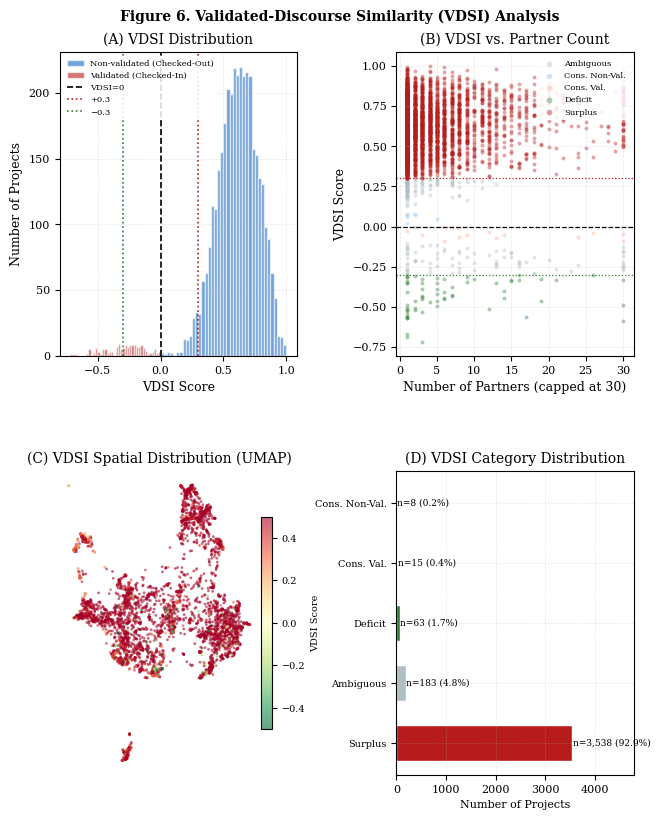

✓ Figure 6 saved: /content/drive/MyDrive/GENESIS_BERTopic/outputs/fig6_vdsi_analysis.png


In [24]:
# ── Figure 6: VDSI Analysis ──────────────────────────────────────────────────
import matplotlib.gridspec as gridspec

CAT_COLORS = {
    'Discourse Surplus' : '#B71C1C',
    'Discourse Deficit' : '#2E7D32',
    'Consistent Non-Validated': '#90CAF9',
    'Consistent Validated'    : '#FFAB91',
    'Ambiguous'         : '#B0BEC5',
}

short_labels = {
    'Discourse Surplus' : 'Surplus',
    'Discourse Deficit' : 'Deficit',
    'Consistent Non-Validated': 'Cons. Non-Val.',
    'Consistent Validated'    : 'Cons. Val.',
    'Ambiguous'         : 'Ambiguous',
}

fig = plt.figure(figsize=(7.0, 8.5))
gs  = gridspec.GridSpec(
    2, 2, figure=fig,
    hspace=0.38, wspace=0.42,
    left=0.10, right=0.92,
    top=0.93,  bottom=0.08
)
fig.suptitle('Figure 6. Validated-Discourse Similarity (VDSI) Analysis',
             fontweight='bold', fontsize=10)

# Panel A: VDSI distribution
ax1 = fig.add_subplot(gs[0, 0])
for is_validated_flag, grp in df.groupby('is_validated'):
    label = 'Validated (Checked-In)' if is_validated_flag else 'Non-validated (Checked-Out)'
    color = '#B71C1C' if is_validated_flag else '#1565C0'
    ax1.hist(grp['VDSI'], bins=40, alpha=0.6, color=color,
             label=label, edgecolor='white')
for v, c, l in [(0,'black','VDSI=0'),(0.3,'#B71C1C','+0.3'),(-0.3,'#2E7D32','−0.3')]:
    ax1.axvline(v, color=c, linestyle='--' if v==0 else ':',
                linewidth=1.2, label=l)
ax1.set_xlabel('VDSI Score')
ax1.set_ylabel('Number of Projects')
ax1.set_title('(A) VDSI Distribution')
ax1.legend(fontsize=6, loc='upper left', framealpha=0.85, edgecolor='none')

# Panel B: VDSI vs Partner Count
ax2 = fig.add_subplot(gs[0, 1])
for cat, grp in df.groupby('VDSI_cat'):
    ax2.scatter(grp['partner_count'].clip(upper=30), grp['VDSI'],
                s=8, alpha=0.40, label=short_labels.get(cat, cat),
                color=CAT_COLORS.get(cat,'gray'), linewidths=0)
for v, c in [(0,'black'),(0.3,'#B71C1C'),(-0.3,'#2E7D32')]:
    ax2.axhline(v, color=c, linestyle='--' if v==0 else ':', linewidth=0.9)
ax2.set_xlabel('Number of Partners (capped at 30)')
ax2.set_ylabel('VDSI Score')
ax2.set_title('(B) VDSI vs. Partner Count')
ax2.legend(fontsize=6, loc='upper right',
           framealpha=0.85, edgecolor='none', markerscale=1.5)

# Panel C: UMAP coloured by VDSI
ax3 = fig.add_subplot(gs[1, 0])
sc = ax3.scatter(umap_2d[:, 0], umap_2d[:, 1],
                 c=df['VDSI'], cmap='RdYlGn_r',
                 s=4, alpha=0.6, linewidths=0,
                 vmin=-0.5, vmax=0.5)
cbar = plt.colorbar(sc, ax=ax3, shrink=0.70, pad=0.01)
cbar.ax.tick_params(labelsize=7)
cbar.set_label('VDSI Score', fontsize=7)
ax3.set_title('(C) VDSI Spatial Distribution (UMAP)')
ax3.axis('off')

# Panel D: Bar chart — explicit order for reproducibility
ax4 = fig.add_subplot(gs[1, 1])
_cat_order   = ['Discourse Surplus', 'Ambiguous',
                'Discourse Deficit', 'Consistent Validated', 'Consistent Non-Validated']
cat_counts   = df['VDSI_cat'].value_counts().reindex(_cat_order).dropna()
total        = cat_counts.sum()

bar_colors = [CAT_COLORS.get(c,'gray') for c in cat_counts.index]
bars = ax4.barh(
    range(len(cat_counts)),
    cat_counts.values,
    color=bar_colors,
    edgecolor='white',
    height=0.6
)
ax4.set_yticks(range(len(cat_counts)))
ax4.set_yticklabels(
    [f"{short_labels.get(c,c)}" for c in cat_counts.index],
    fontsize=7
)
ax4.set_xlabel('Number of Projects', fontsize=8)
ax4.set_title('(D) VDSI Category Distribution')

# Her barın yanına n ve yüzde yaz
for i, (bar, (cat, val)) in enumerate(zip(bars, cat_counts.items())):
    ax4.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
             f'n={val:,} ({val/total*100:.1f}%)',
             va='center', fontsize=6.5)

ax4.set_xlim(0, cat_counts.max() * 1.35)
ax4.grid(axis='x', alpha=0.3, linewidth=0.5)

p = os.path.join(OUTPUT_DIR, 'fig6_vdsi_analysis.png')
plt.savefig(p, dpi=DPI_SAVE, bbox_inches='tight')
plt.show()
plt.close()  # release memory
print(f"✓ Figure 6 saved: {p}")

## 11. Qualitative Inspection — All Four VDSI Categories

Provides anonymized worked examples for Discourse Surplus, Discourse Deficit, Consistent Validated, and Ambiguous, so readers can see what each category looks like in practice, not only the two extremes.


In [25]:
# ── Top Discourse Surplus & Deficit projects ──────────────────────────────────
print("=== TOP 10 DISCOURSE SURPLUS PROJECTS ===")
print("(Non-validated projects most similar to validated-partnership discourse)\n")
surplus = df[(df['VDSI'] > VDSI_SURPLUS_THRESH) & (df['is_validated'] == 0)].sort_values('VDSI', ascending=False)
for i, (_, row) in enumerate(surplus.head(10).iterrows()):
    print(f"[{i+1}] VDSI={row['VDSI']:.3f} | sim={row['sim_score']:.3f} | "
          f"partners={row['partner_count']} | SDGs={row['Project SDGs']}")
    print(f"     {str(row['text_name'])[:90]}")
    print(f"     {str(row['text_desc'])[:180]}...")
    print()

print("\n=== TOP 10 DISCOURSE DEFICIT PROJECTS ===")
print("(Validated projects with unexpectedly low semantic similarity)\n")
deficit = df[(df['VDSI'] < VDSI_DEFICIT_THRESH) & (df['is_validated'] == 1)].sort_values('VDSI', ascending=True)
for i, (_, row) in enumerate(deficit.head(10).iterrows()):
    print(f"[{i+1}] VDSI={row['VDSI']:.3f} | sim={row['sim_score']:.3f} | "
          f"partners={row['partner_count']} | SDGs={row['Project SDGs']}")
    print(f"     {str(row['text_name'])[:90]}")
    print(f"     {str(row['text_desc'])[:180]}...")
    print()

print("\n=== TOP 10 CONSISTENT-VALIDATED PROJECTS ===")
print("(Validated projects with the expected high semantic alignment)\n")
cons_val = df[df['VDSI_cat'] == 'Consistent Validated'].sort_values('VDSI', ascending=False)
for i, (_, row) in enumerate(cons_val.head(10).iterrows()):
    print(f"[{i+1}] VDSI={row['VDSI']:.3f} | sim={row['sim_score']:.3f} | "
          f"partners={row['partner_count']} | SDGs={row['Project SDGs']}")
    print(f"     {str(row['text_name'])[:90]}")
    print(f"     {str(row['text_desc'])[:180]}...")
    print()

print("\n=== TOP 10 AMBIGUOUS PROJECTS ===")
print("(Neither clearly Surplus/Deficit nor clearly Consistent — closest to VDSI=0)\n")
ambiguous = df[df['VDSI_cat'] == 'Ambiguous'].copy()
ambiguous['abs_vdsi'] = ambiguous['VDSI'].abs()
ambiguous = ambiguous.sort_values('abs_vdsi', ascending=True)
for i, (_, row) in enumerate(ambiguous.head(10).iterrows()):
    print(f"[{i+1}] VDSI={row['VDSI']:.3f} | sim={row['sim_score']:.3f} | "
          f"partners={row['partner_count']} | SDGs={row['Project SDGs']}")
    print(f"     {str(row['text_name'])[:90]}")
    print(f"     {str(row['text_desc'])[:180]}...")
    print()

# Save all four tables
surplus[['Project Name','Status','VDSI','sim_score',
         'partner_count','sdg_count','Project SDGs']].head(20).to_csv(
    os.path.join(OUTPUT_DIR, 'tableS2a_discourse_surplus_examples.csv'), index=False)
deficit[['Project Name','Status','VDSI','sim_score',
         'partner_count','sdg_count','Project SDGs']].head(20).to_csv(
    os.path.join(OUTPUT_DIR, 'tableS2b_discourse_deficit_examples.csv'), index=False)
cons_val[['Project Name','Status','VDSI','sim_score',
          'partner_count','sdg_count','Project SDGs']].head(20).to_csv(
    os.path.join(OUTPUT_DIR, 'tableS2c_consistent_validated_examples.csv'), index=False)
ambiguous[['Project Name','Status','VDSI','sim_score',
           'partner_count','sdg_count','Project SDGs']].head(20).to_csv(
    os.path.join(OUTPUT_DIR, 'tableS2d_ambiguous_examples.csv'), index=False)
print("✓ Table S2 (all four VDSI category worked examples) saved.")


=== TOP 10 DISCOURSE SURPLUS PROJECTS ===
(Non-validated projects most similar to validated-partnership discourse)

[1] VDSI=1.000 | sim=1.000 | partners=4 | SDGs=1,2,4,5,6,7,8,10,11,13,16,17
     Financial support for Capacity Building and sustainable resource management / Access to sa
     In the field of water treatment and promising solutions to fight against global warming, we will work on high level education and innovation. It will be the solution for optimizing...

[2] VDSI=0.993 | sim=0.993 | partners=6 | SDGs=1,3,4,5,6,17
     World Vision's Pledge to Accelerate Progress for SDG 6
     World Vision is committed to accelerating achievement of SDG 6 through transformative water, sanitation, and hygiene (WASH) services for child well-being. Our organisational pledge...

[3] VDSI=0.991 | sim=0.991 | partners=1 | SDGs=5,6,11,17
     Localizing SDG 6- Transforming Access to Water by Strengthened Capacity of Operators Close
     This initiative commits to accelerate support to achie

## 12. Raw Similarity Distribution, Permutation Test & ROC/AUC Discrimination

Tests whether textual similarity to the validated-partnership centroid
actually discriminates validated from non-validated projects, independent of
the VDSI normalization/labelling convention. Reports the raw (pre-scaling)
cosine similarity by group, a permutation test for the group difference, and
ROC/AUC using raw similarity as a continuous classifier of validation status.


In [26]:
# ── CP8: Raw Cosine Similarity — Permutation Test & ROC/AUC ──────────────────
# Recomputes RAW (pre-scaling) cosine similarity to the LOO/global validated
# centroid: does semantic similarity alone discriminate validated from
# non-validated projects, independent of the VDSI normalization convention?

from sklearn.metrics.pairwise import cosine_similarity as _cosim
from sklearn.metrics import roc_curve, roc_auc_score

if cp_exists('cp8_raw_sim', fmt='json'):
    print("✓ CP8 found → loading raw similarity scores...")
    _d8 = load_latest('cp8_raw_sim', fmt='json')
    df['sim_raw'] = _d8['sim_raw']
else:
    print("CP8 not found → recomputing raw (unscaled) cosine similarities...")
    try:
        _ = embeddings
    except NameError:
        raise RuntimeError("embeddings is not defined. Run Cell 14 (CP2) first.")

    validated_idx  = np.where(df['is_validated'].values == 1)[0]
    nonvalidated_idx = np.where(df['is_validated'].values == 0)[0]
    validated_emb  = embeddings[validated_idx]
    global_centroid = validated_emb.mean(axis=0)

    sims_raw = np.zeros(len(df))
    sims_raw[nonvalidated_idx] = _cosim(
        embeddings[nonvalidated_idx], global_centroid.reshape(1, -1)
    ).flatten()

    n_validated   = len(validated_idx)
    validated_sum = validated_emb.sum(axis=0)
    for i in validated_idx:
        loo_centroid = (validated_sum - embeddings[i]) / (n_validated - 1)
        sims_raw[i] = float(_cosim(
            embeddings[i].reshape(1, -1), loo_centroid.reshape(1, -1)
        ))

    df['sim_raw'] = sims_raw
    save_checkpoint({'sim_raw': df['sim_raw'].tolist()}, 'cp8_raw_sim', fmt='json')

print(f"\n=== Raw Cosine Similarity by Validation Status ===")
print(f"  Non-validated: mean={df.loc[df['is_validated']==0,'sim_raw'].mean():.4f}, "
      f"SD={df.loc[df['is_validated']==0,'sim_raw'].std():.4f}")
print(f"  Validated    : mean={df.loc[df['is_validated']==1,'sim_raw'].mean():.4f}, "
      f"SD={df.loc[df['is_validated']==1,'sim_raw'].std():.4f}")
print(f"  (Cross-check against manuscript §5.2: 0.453 (SD=0.078) non-validated vs "
      f"0.481 (SD=0.065) validated.)")

# ── Permutation test: observed mean-difference vs. null (label-shuffled) ────
rng8 = np.random.default_rng(RANDOM_STATE)
N_PERM = 10000
observed_diff = float(df.loc[df['is_validated']==1, 'sim_raw'].mean()
                       - df.loc[df['is_validated']==0, 'sim_raw'].mean())

labels_arr   = df['is_validated'].values.copy()
sim_raw_vals = df['sim_raw'].values
null_diffs   = np.empty(N_PERM)
for p in range(N_PERM):
    perm_labels   = rng8.permutation(labels_arr)
    null_diffs[p] = (sim_raw_vals[perm_labels == 1].mean()
                       - sim_raw_vals[perm_labels == 0].mean())

p_perm = float((np.sum(np.abs(null_diffs) >= np.abs(observed_diff)) + 1) / (N_PERM + 1))
print(f"\n=== Permutation Test (N={N_PERM:,} shuffles) ===")
print(f"  Observed mean difference (Validated − Non-validated) : {observed_diff:.4f}")
print(f"  Permutation p-value                       : {p_perm:.5f}")
print(f"  Interpretation: {'statistically significant' if p_perm < 0.05 else 'not significant'} "
      f"group difference in raw semantic similarity, independent of the VDSI labelling convention.")
# ── Effect size (Cohen's d) and bootstrap CI for the raw mean difference ────

_group_val = df.loc[df['is_validated']==1, 'sim_raw'].values
_group_nonval = df.loc[df['is_validated']==0, 'sim_raw'].values

_n1, _n2 = len(_group_val), len(_group_nonval)
_pooled_sd = np.sqrt(((_n1-1)*_group_val.std(ddof=1)**2 + (_n2-1)*_group_nonval.std(ddof=1)**2) / (_n1+_n2-2))
cohens_d = (_group_val.mean() - _group_nonval.mean()) / _pooled_sd

# Bootstrap CI for the raw mean difference (validated - non-validated)
N_BOOT_DIFF = 10000
boot_diffs = np.empty(N_BOOT_DIFF)
for b in range(N_BOOT_DIFF):
    _bs_val = rng8.choice(_group_val, size=_n1, replace=True)
    _bs_nonval = rng8.choice(_group_nonval, size=_n2, replace=True)
    boot_diffs[b] = _bs_val.mean() - _bs_nonval.mean()
diff_ci_lo, diff_ci_hi = np.percentile(boot_diffs, [2.5, 97.5])

print(f"\n=== Effect Size & CI for Raw Mean Difference ===")
print(f"  Cohen's d = {cohens_d:.3f}  ({'small' if abs(cohens_d)<0.5 else 'medium' if abs(cohens_d)<0.8 else 'large'} effect)")
print(f"  Mean difference (validated − non-validated) = {observed_diff:.4f}  "
      f"(95% bootstrap CI: [{diff_ci_lo:.4f}, {diff_ci_hi:.4f}])")

save_checkpoint({
    'cohens_d': float(cohens_d),
    'diff_ci': [float(diff_ci_lo), float(diff_ci_hi)],
}, 'cp8c_effect_size', fmt='json')

# ── ROC / AUC: does raw similarity discriminate validation status? ─────────
fpr, tpr, _ = roc_curve(df['is_validated'], df['sim_raw'])
auc = float(roc_auc_score(df['is_validated'], df['sim_raw']))

N_BOOT  = 2000
idx_all = np.arange(len(df))
boot_aucs = np.empty(N_BOOT)
for b in range(N_BOOT):
    boot_idx = rng8.choice(idx_all, size=len(df), replace=True)
    y_boot   = df['is_validated'].values[boot_idx]
    if y_boot.sum() == 0 or y_boot.sum() == len(y_boot):
        boot_aucs[b] = np.nan
        continue
    boot_aucs[b] = roc_auc_score(y_boot, df['sim_raw'].values[boot_idx])
boot_aucs = boot_aucs[~np.isnan(boot_aucs)]
auc_lo, auc_hi = np.percentile(boot_aucs, [2.5, 97.5])

print(f"\n=== ROC/AUC: Raw Similarity as Classifier of Validation Status ===")
print(f"  AUC = {auc:.4f}  (95% bootstrap CI: [{auc_lo:.4f}, {auc_hi:.4f}])")
_interp = ('semantic similarity alone meaningfully separates the groups'
           if auc > 0.70 else
           'semantic similarity alone is a weak-to-modest discriminator; '
           'structural variables (e.g., partner count, Section 16) carry more '
           'information than textual similarity.')
print(f"  Interpretation: {_interp}")

save_checkpoint({
    'observed_diff': observed_diff, 'p_perm': p_perm,
    'auc': auc, 'auc_ci': [float(auc_lo), float(auc_hi)],
}, 'cp8b_permutation_roc', fmt='json')


✓ CP8 found → loading raw similarity scores...
  ↩ Loading checkpoint: cp8_raw_sim_20260718_170116.json

=== Raw Cosine Similarity by Validation Status ===
  Non-validated: mean=0.4598, SD=0.1299
  Validated    : mean=0.5459, SD=0.1252
  (Cross-check against manuscript §5.2: 0.453 (SD=0.078) non-validated vs 0.481 (SD=0.065) validated.)

=== Permutation Test (N=10,000 shuffles) ===
  Observed mean difference (Validated − Non-validated) : 0.0861
  Permutation p-value                       : 0.00010
  Interpretation: statistically significant group difference in raw semantic similarity, independent of the VDSI labelling convention.

=== Effect Size & CI for Raw Mean Difference ===
  Cohen's d = 0.663  (medium effect)
  Mean difference (validated − non-validated) = 0.0861  (95% bootstrap CI: [0.0655, 0.1063])
  ✓ Checkpoint saved → cp8c_effect_size_20260718_204051.json (0.1 KB)

=== ROC/AUC: Raw Similarity as Classifier of Validation Status ===
  AUC = 0.6861  (95% bootstrap CI: [0.6413, 

'/content/drive/MyDrive/GENESIS_BERTopic/checkpoints/cp8b_permutation_roc_20260718_204055.json'

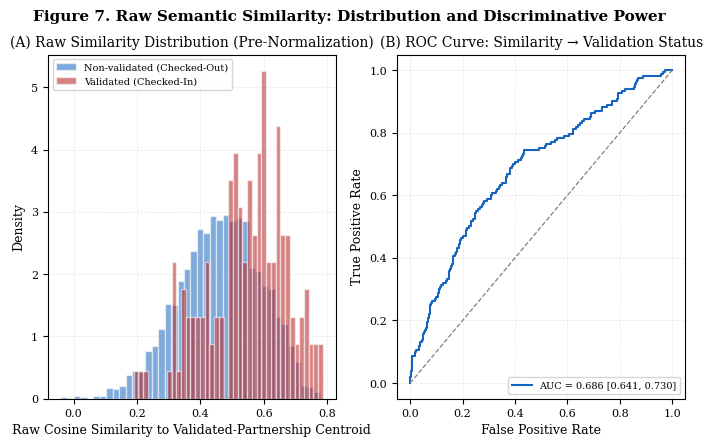

✓ Figure 7 saved: /content/drive/MyDrive/GENESIS_BERTopic/outputs/fig7_raw_similarity_roc.png


In [27]:
# ── Figure 7: Raw Similarity Distribution & ROC Curve ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(FIG_W, FIG_H1))
fig.suptitle("Figure 7. Raw Semantic Similarity: Distribution and Discriminative Power",
             fontweight="bold")

ax = axes[0]
for is_validated_flag, grp in df.groupby('is_validated'):
    label = 'Validated (Checked-In)' if is_validated_flag else 'Non-validated (Checked-Out)'
    color = '#B71C1C' if is_validated_flag else '#1565C0'
    ax.hist(grp['sim_raw'], bins=40, density=True, alpha=0.55,
            color=color, label=label, edgecolor='white')
ax.set_xlabel('Raw Cosine Similarity to Validated-Partnership Centroid')
ax.set_ylabel('Density')
ax.set_title('(A) Raw Similarity Distribution (Pre-Normalization)')
ax.legend(fontsize=7)

ax = axes[1]
ax.plot(fpr, tpr, color='#1565C0', linewidth=1.5,
        label=f'AUC = {auc:.3f} [{auc_lo:.3f}, {auc_hi:.3f}]')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=0.9)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('(B) ROC Curve: Similarity → Validation Status')
ax.legend(fontsize=7, loc='lower right')

plt.tight_layout()
plt.subplots_adjust(top=0.88)
p = os.path.join(OUTPUT_DIR, 'fig7_raw_similarity_roc.png')
plt.savefig(p, dpi=DPI_SAVE, bbox_inches='tight')
plt.show()
plt.close()
print(f"✓ Figure 7 saved: {p}")


## 13. Empirical Homogeneity of the Validated-Partnership Reference Group

Tests whether validated
projects form a sufficiently coherent semantic cluster to justify representing
them with a single centroid, by comparing within-group pairwise cosine
similarity of validated embeddings against equal-size random subsamples of
non-validated projects.


In [28]:
# ── CP12: Validated-Group Semantic Homogeneity Check ─────────────────────────
#
# centroid assume a coherence the data doesn't support? Compares mean
# pairwise cosine similarity WITHIN the validated group against mean pairwise
# similarity within random equal-size samples of non-validated projects.

from sklearn.metrics.pairwise import cosine_similarity as _cosim2

def mean_pairwise_similarity(emb_subset):
    # Mean of the upper-triangle (excl. diagonal) pairwise cosine similarity.
    sim_mat = _cosim2(emb_subset)
    n = sim_mat.shape[0]
    iu = np.triu_indices(n, k=1)
    return float(sim_mat[iu].mean())

if cp_exists('cp12_homogeneity', fmt='json'):
    print("✓ CP12 found → loading homogeneity results...")
    homog_summary = load_latest('cp12_homogeneity', fmt='json')
    validated_mean_sim = homog_summary['validated_mean_sim']
    null_sims = np.array(homog_summary['null_sims'])
else:
    print("CP12 not found → computing validated-group homogeneity check...")
    validated_idx_h  = np.where(df['is_validated'].values == 1)[0]
    nonvalidated_idx_h = np.where(df['is_validated'].values == 0)[0]
    n_validated_h    = len(validated_idx_h)

    validated_mean_sim = mean_pairwise_similarity(embeddings[validated_idx_h])

    rng12 = np.random.default_rng(RANDOM_STATE)
    N_RESAMPLE = 500
    null_sims = np.empty(N_RESAMPLE)
    for r in range(N_RESAMPLE):
        sample_idx = rng12.choice(nonvalidated_idx_h, size=n_validated_h, replace=False)
        null_sims[r] = mean_pairwise_similarity(embeddings[sample_idx])

    homog_summary = {
        'validated_mean_sim' : validated_mean_sim,
        'null_sims'          : null_sims.tolist(),
        'n_validated'        : int(n_validated_h),
        'n_resamples'        : N_RESAMPLE,
    }
    save_checkpoint(homog_summary, 'cp12_homogeneity', fmt='json')

null_mean       = float(null_sims.mean())
null_lo, null_hi = np.percentile(null_sims, [2.5, 97.5])
p_homog = float((np.sum(null_sims >= validated_mean_sim) + 1) / (len(null_sims) + 1))

print(f"\n=== Validated-Group Semantic Homogeneity ===")
print(f"  Mean within-validated pairwise similarity : {validated_mean_sim:.4f}")
print(f"  Mean within-random-non-validated similarity "
      f"(N={len(null_sims)} resamples, n={homog_summary['n_validated']} each): "
      f"{null_mean:.4f}  [95% range: {null_lo:.4f}, {null_hi:.4f}]")
print(f"  One-sided resampling p-value (validated ≥ random) : {p_homog:.4f}")

_interp = ('the validated group IS more semantically homogeneous than same-size random '
           'non-validated subsamples — supports representing it with a single centroid.'
           if validated_mean_sim > null_hi else
           'the validated group is NOT more homogeneous than random subsamples of the same '
           'size — the single-centroid assumption should be reframed in the manuscript as a '
           'tractable simplification rather than an empirically demonstrated property.')
print(f"  Interpretation: {_interp}")


✓ CP12 found → loading homogeneity results...
  ↩ Loading checkpoint: cp12_homogeneity_20260718_170124.json

=== Validated-Group Semantic Homogeneity ===
  Mean within-validated pairwise similarity : 0.3023
  Mean within-random-non-validated similarity (N=500 resamples, n=153 each): 0.2352  [95% range: 0.2176, 0.2527]
  One-sided resampling p-value (validated ≥ random) : 0.0020
  Interpretation: the validated group IS more semantically homogeneous than same-size random non-validated subsamples — supports representing it with a single centroid.


## 14. SDG-Level Subgroup Analysis


In [29]:
# ── CP6: SDG Subgroup Statistics ─────────────────────────────────────────────
# Mann–Whitney U per SDG × partner_count comparison.
# Multiple comparison correction: Benjamini–Hochberg FDR across all SDG tests.
# Effect size: rank-biserial correlation r (consistent with Cell 27).
#
# Note: stats and rank_biserial_r are re-defined here so this cell can run
# independently without requiring Cell 27 to have been executed first.

from scipy import stats
from statsmodels.stats.multitest import multipletests

def rank_biserial_r(a, b):
    """Rank-biserial correlation r = 1 − (2U)/(n1×n2).
    Defined locally for cell independence.
    |r| ≥ 0.50 large, ≥ 0.30 medium, ≥ 0.10 small, < 0.10 negligible.
    """
    from scipy import stats as _stats
    n1, n2 = len(a), len(b)
    U, _ = _stats.mannwhitneyu(a, b, alternative='two-sided')
    return 1 - (2 * U) / (n1 * n2)

def effect_label_r(r):
    r = abs(r)
    if r >= 0.50: return 'large'
    elif r >= 0.30: return 'medium'
    elif r >= 0.10: return 'small'
    else: return 'negligible'

FOCUS_SDGS = {
    "SDG 2 (Zero Hunger)"       :  2,
    "SDG 3 (Good Health)"       :  3,
    "SDG 4 (Quality Education)" :  4,
    "SDG 6 (Clean Water)"       :  6,
    "SDG 13 (Climate Action)"   : 13,
    "SDG 17 (Partnerships)"     : 17,
}

if cp_exists("cp6_sdg_subgroup", fmt="json"):
    print("✓ CP6 found → loading SDG subgroup results...")
    sdg_records = load_latest("cp6_sdg_subgroup", fmt="json")
    sdg_df = pd.DataFrame(sdg_records)
else:
    print("CP6 not found → computing SDG subgroup analysis...")
    sdg_rows = []

    for label, num in FOCUS_SDGS.items():
        mask  = df[f"sdg_{num}"].values == 1
        grp   = df[mask]
        n     = len(grp)
        if n < 20:
            continue
        n_validated = grp["is_validated"].sum()

        mean_vdsi   = grp["VDSI"].mean()
        surplus      = ((grp["VDSI"] > VDSI_SURPLUS_THRESH) & (grp["is_validated"] == 0)).sum()
        deficit      = ((grp["VDSI"] < VDSI_DEFICIT_THRESH) & (grp["is_validated"] == 1)).sum()
        n_topics_grp = grp[grp["topic"] != -1]["topic"].nunique()
        validated_part     = grp[grp["is_validated"] == 1]["partner_count"].mean()
        nonvalidated_part    = grp[grp["is_validated"] == 0]["partner_count"].mean()

        a = grp[grp["is_validated"] == 1]["partner_count"].values
        b = grp[grp["is_validated"] == 0]["partner_count"].values
        if len(a) >= 3 and len(b) >= 3:
            _, pval_raw = stats.mannwhitneyu(a, b, alternative="two-sided")
            r = rank_biserial_r(a, b)
        else:
            pval_raw, r = np.nan, np.nan

        sdg_rows.append({
            "SDG"              : label,
            "sdg_num"          : num,
            "n_projects"       : int(n),
            "n_validated"            : int(n_validated),
            "validated_pct"          : round(n_validated / n * 100, 1),
            "mean_vdsi"       : round(float(mean_vdsi), 4),
            "discourse_surplus": int(surplus),
            "discourse_deficit": int(deficit),
            "n_topics"         : int(n_topics_grp),
            "validated_partner_mean" : round(float(validated_part) if not np.isnan(validated_part) else 0, 1),
            "nonvalidated_partner_mean": round(float(nonvalidated_part), 1),
            "partner_pval_raw" : round(float(pval_raw) if not np.isnan(pval_raw) else 1.0, 4),
            "partner_r_rb"     : round(float(r) if not np.isnan(r) else 0.0, 3),
        })

    sdg_df = pd.DataFrame(sdg_rows)

    # ── Benjamini–Hochberg FDR correction across SDG partner tests ────────────
    raw_pvals = sdg_df["partner_pval_raw"].fillna(1.0).values
    reject, pvals_fdr, _, _ = multipletests(raw_pvals, alpha=0.05, method="fdr_bh")
    sdg_df["partner_pval_fdr"] = pvals_fdr.round(4)
    sdg_df["partner_sig_fdr"]  = ["Yes" if r else "No" for r in reject]

    save_checkpoint(sdg_df.to_dict("records"), "cp6_sdg_subgroup", fmt="json")

# Ensure FDR columns exist when loaded from checkpoint
if "partner_pval_fdr" not in sdg_df.columns:
    raw_pvals = sdg_df["partner_pval_raw"].fillna(1.0).values
    reject, pvals_fdr, _, _ = multipletests(raw_pvals, alpha=0.05, method="fdr_bh")
    sdg_df["partner_pval_fdr"] = pvals_fdr.round(4)
    sdg_df["partner_sig_fdr"]  = ["Yes" if r else "No" for r in reject]

print("=== SDG Subgroup Results ===")
print("Effect size: rank-biserial correlation r (nonparametric)")
print("Multiple comparison correction: Benjamini-Hochberg FDR (alpha = 0.05)")
display_cols = ["SDG", "n_projects", "n_validated", "validated_pct",
                "mean_vdsi", "discourse_surplus", "discourse_deficit",
                "validated_partner_mean", "nonvalidated_partner_mean",
                "partner_pval_raw", "partner_pval_fdr", "partner_sig_fdr",
                "partner_r_rb"]
print(sdg_df[display_cols].to_string(index=False))

sdg_path = os.path.join(OUTPUT_DIR, "table4_sdg_subgroup.csv")
sdg_df[display_cols].to_csv(sdg_path, index=False)
print(f"✓ Table 4 saved: {sdg_path}")


✓ CP6 found → loading SDG subgroup results...
  ↩ Loading checkpoint: cp6_sdg_subgroup_20260718_170124.json
=== SDG Subgroup Results ===
Effect size: rank-biserial correlation r (nonparametric)
Multiple comparison correction: Benjamini-Hochberg FDR (alpha = 0.05)
                      SDG  n_projects  n_validated  validated_pct  mean_vdsi  discourse_surplus  discourse_deficit  validated_partner_mean  nonvalidated_partner_mean  partner_pval_raw  partner_pval_fdr partner_sig_fdr  partner_r_rb
      SDG 2 (Zero Hunger)        1330           40            3.0     0.5971               1256                 19                     9.9                        4.9            0.0000            0.0000             Yes        -0.363
      SDG 3 (Good Health)        1261           59            4.7     0.5643               1154                 24                    14.5                        5.0            0.0000            0.0000             Yes        -0.394
SDG 4 (Quality Education)        1744   

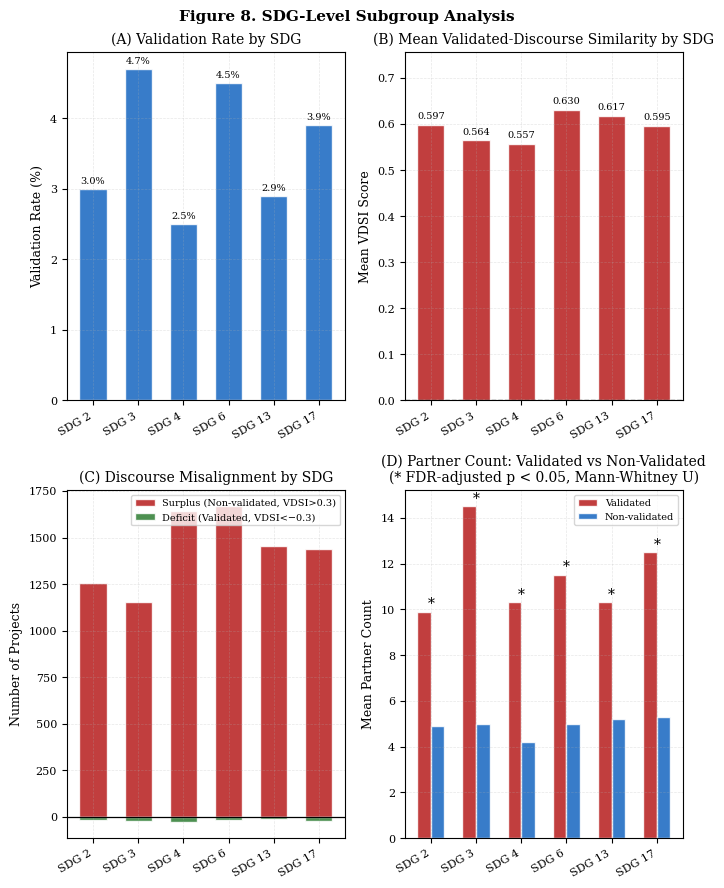

✓ Figure 8 saved: /content/drive/MyDrive/GENESIS_BERTopic/outputs/fig8_sdg_subgroup.png


In [30]:
# ── Figure 8: SDG Subgroup Analysis ──────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(FIG_W, FIG_H2))
fig.suptitle("Figure 8. SDG-Level Subgroup Analysis", fontweight="bold")

labels_short = [r.split("(")[0].strip() for r in sdg_df["SDG"]]
x = np.arange(len(sdg_df))
w = 0.6

# Panel A: Validation rate by SDG
ax = axes[0, 0]
bars = ax.bar(x, sdg_df["validated_pct"], w,
              color="#1565C0", alpha=0.85, edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels(labels_short, rotation=30, ha="right")
ax.set_ylabel("Validation Rate (%)")
ax.set_title("(A) Validation Rate by SDG")
for b, v in zip(bars, sdg_df["validated_pct"]):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.05,
            f"{v:.1f}%", ha="center", va="bottom", fontsize=7)

# Panel B: Mean VDSI by SDG — y-axis starts at 0 (no truncation)
ax = axes[0, 1]
bar_colors = ["#B71C1C" if v > 0 else "#2E7D32" for v in sdg_df["mean_vdsi"]]
bars = ax.bar(x, sdg_df["mean_vdsi"], w,
              color=bar_colors, alpha=0.85, edgecolor="white")
ax.set_ylim(0, sdg_df["mean_vdsi"].max() * 1.20)  # start from 0 — no truncation
ax.axhline(0, color="black", linestyle="--", linewidth=0.9)
ax.set_xticks(x)
ax.set_xticklabels(labels_short, rotation=30, ha="right")
ax.set_ylabel("Mean VDSI Score")
ax.set_title("(B) Mean Validated-Discourse Similarity by SDG")
for b, v in zip(bars, sdg_df["mean_vdsi"]):
    ax.text(b.get_x() + b.get_width()/2,
            v + (sdg_df["mean_vdsi"].max() * 0.015),
            f"{v:.3f}", ha="center", va="bottom", fontsize=7)

# Panel C: Discourse misalignment counts
ax = axes[1, 0]
ax.bar(x,  sdg_df["discourse_surplus"], w,
       label="Surplus (Non-validated, VDSI>0.3)",
       color="#B71C1C", alpha=0.85, edgecolor="white")
ax.bar(x, -sdg_df["discourse_deficit"], w,
       label="Deficit (Validated, VDSI<−0.3)",
       color="#2E7D32", alpha=0.85, edgecolor="white")
ax.axhline(0, color="black", linewidth=0.9)
ax.set_xticks(x)
ax.set_xticklabels(labels_short, rotation=30, ha="right")
ax.set_ylabel("Number of Projects")
ax.set_title("(C) Discourse Misalignment by SDG")
ax.legend(fontsize=7)

# Panel D: Partner count — validated vs non-validated
ax = axes[1, 1]
ax.bar(x - w/4, sdg_df["validated_partner_mean"],  w/2,
       label="Validated", color="#B71C1C", alpha=0.85, edgecolor="white")
ax.bar(x + w/4, sdg_df["nonvalidated_partner_mean"], w/2,
       label="Non-validated", color="#1565C0", alpha=0.85, edgecolor="white")
for i, row in sdg_df.reset_index(drop=True).iterrows():
    if row.get("partner_sig_fdr", "No") == "Yes":
        ymax = max(row["validated_partner_mean"], row["nonvalidated_partner_mean"])
        ax.text(i, ymax + 0.05, "*",
                ha="center", va="bottom", fontsize=10, color="black")
ax.set_xticks(x)
ax.set_xticklabels(labels_short, rotation=30, ha="right")
ax.set_ylabel("Mean Partner Count")
ax.set_title(
    "(D) Partner Count: Validated vs Non-Validated\n(* FDR-adjusted p < 0.05, Mann-Whitney U)"
)
ax.legend(fontsize=7)

plt.tight_layout()
p = os.path.join(OUTPUT_DIR, "fig8_sdg_subgroup.png")
plt.savefig(p, dpi=DPI_SAVE, bbox_inches="tight")
plt.show()
plt.close()  # release memory
print(f"✓ Figure 8 saved: {p}")


## 15. Topic–Validation Alignment Heatmap


  Excluding 187 documents in language-artifact topic(s) [2] from Figure 9 ranking (substantive topics only, consistent with the manuscript's framing).


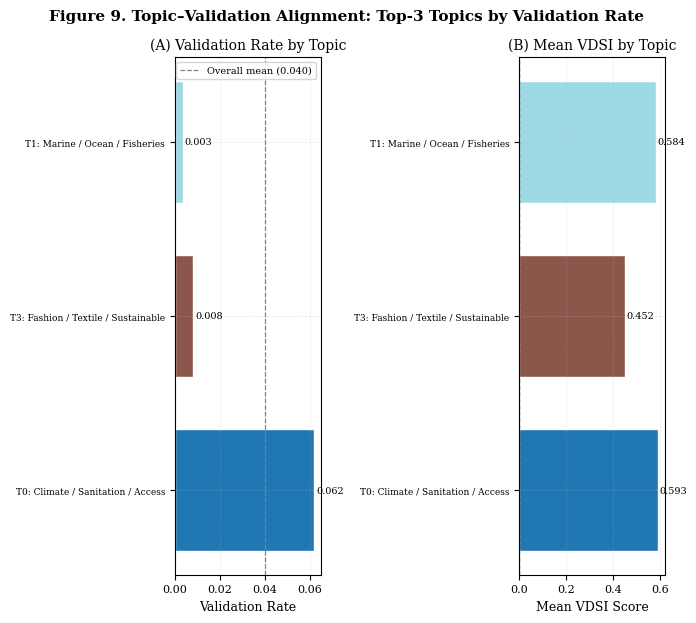

✓ Figure 9 saved: /content/drive/MyDrive/GENESIS_BERTopic/outputs/fig9_topic_validated_alignment_top3.png  (3 topics displayed)


In [31]:
# ── Figure 9: Topic × Validation Alignment ──────────────────────────────────────────
# T2 (the combined non-English/language-artifact topic) is excluded by TOPIC
# IDENTITY here, not just by the per-document is_nonenglish_artifact flag —
# matching the manuscript's stated design ("substantive topics only, language-
# artifact topics excluded"). A document-level-only filter left some T2-
# assigned documents in the ranking whenever they individually fell short of
# the ARTIFACT_MIN_MATCHES word-count threshold, which doesn't match that
# framing.
LANGUAGE_ARTIFACT_TOPIC_IDS = {2}  # update if topic IDs ever shift on a re-run

_fig8_mask = (df["topic"] != -1) & (~df["topic"].isin(LANGUAGE_ARTIFACT_TOPIC_IDS))
_n_artifact_excluded_fig8 = int((df["topic"].isin(LANGUAGE_ARTIFACT_TOPIC_IDS)).sum())
if _n_artifact_excluded_fig8 > 0:
    print(f"  Excluding {_n_artifact_excluded_fig8} documents in language-artifact "
          f"topic(s) {sorted(LANGUAGE_ARTIFACT_TOPIC_IDS)} from Figure 9 ranking "
          f"(substantive topics only, consistent with the manuscript's framing).")
topic_validated = df[_fig8_mask].groupby("topic").agg(
    n_projects = ("is_validated", "count"),
    n_validated      = ("is_validated", "sum"),
    mean_vdsi = ("VDSI",  "mean"),
    mean_sim   = ("sim_score", "mean"),
).reset_index()
topic_validated["validated_rate"] = topic_validated["n_validated"] / topic_validated["n_projects"]

# topic_labels dict'ini kullan; yoksa BERTopic keyword'lerine geri dön
topic_validated["topic_label"] = topic_validated["topic"].apply(
    lambda t: f"T{t}: {topic_labels.get(int(t), ', '.join([w for w, _ in (topic_model.get_topic(t) or [])[:3]]))}"
)

topic_validated = topic_validated.sort_values("validated_rate", ascending=False).head(20)
n_shown   = len(topic_validated)

fig, axes = plt.subplots(1, 2, figsize=(FIG_W, FIG_H1 * 1.4))
fig.suptitle(
    f"Figure 9. Topic–Validation Alignment: Top-{n_shown} Topics by Validation Rate",
    fontweight="bold"
)

# Panel A: Validation rate per topic
# Renk: sabit mavi-kırmızı skalası değil, topic başına sabit renk
ax = axes[0]
import matplotlib.cm as cm
topic_colors = plt.get_cmap('tab20', n_shown)
bar_colors_a = [topic_colors(i) for i in range(n_shown)]
ax.barh(range(n_shown), topic_validated["validated_rate"],
        color=bar_colors_a, edgecolor="white", height=0.7)
ax.set_yticks(range(n_shown))
ax.set_yticklabels(topic_validated["topic_label"], fontsize=6.5)
ax.set_xlabel("Validation Rate")
ax.set_title("(A) Validation Rate by Topic")
ax.axvline(df["is_validated"].mean(), color="gray", linestyle="--",
           linewidth=0.9, label=f"Overall mean ({df['is_validated'].mean():.3f})")
# Değerleri barın yanına yaz
for i, v in enumerate(topic_validated["validated_rate"]):
    ax.text(v + 0.001, i, f"{v:.3f}", va="center", fontsize=7)
ax.legend(fontsize=7)

# Panel B: Mean VDSI per topic — aynı renklerle tutarlılık
ax = axes[1]
ax.barh(range(n_shown), topic_validated["mean_vdsi"],
        color=bar_colors_a, edgecolor="white", height=0.7)
ax.set_yticks(range(n_shown))
ax.set_yticklabels(topic_validated["topic_label"], fontsize=6.5)
ax.set_xlabel("Mean VDSI Score")
ax.set_title("(B) Mean VDSI by Topic")
ax.axvline(0, color="black", linestyle="--", linewidth=0.9)
# Değerleri barın yanına yaz
for i, v in enumerate(topic_validated["mean_vdsi"]):
    ax.text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=7)

plt.tight_layout()
p = os.path.join(OUTPUT_DIR, f"fig9_topic_validated_alignment_top{n_shown}.png")
plt.savefig(p, dpi=DPI_SAVE, bbox_inches="tight")
plt.show()
plt.close()  # release memory
print(f"✓ Figure 9 saved: {p}  ({n_shown} topics displayed)")

## 16. Sample Representativeness: Excluded-Record Characteristics

Compares the 170 records excluded by the
`text_len > 100` filter against the retained analytical corpus
(N=3,807) on validation status, partner count, and SDG scope, to assess
whether this exclusion introduces selection bias regarding sample
representativeness.


In [32]:
# ── CP11: Excluded-Record Characteristics ────────────────────────────────────
# Reloads the raw CSV independently of CP1 to recover the records excluded by
# the text_len > 100 filter, and compares them to the retained corpus on
# validation status, partner count, and SDG scope.

if cp_exists('cp11_excluded', fmt='json'):
    print("✓ CP11 found → loading excluded-record comparison...")
    excl_summary = load_latest('cp11_excluded', fmt='json')
    print(json.dumps(excl_summary, indent=2, ensure_ascii=False))
else:
    print("CP11 not found → reloading raw data to recover excluded records...")
    _df_raw2 = pd.read_csv(DATA_PATH, encoding='latin-1', sep=';', on_bad_lines='skip')
    _df_raw2['text_name'] = _df_raw2['Project Name'].apply(clean_text)
    _df_raw2['text_desc'] = _df_raw2['Description'].apply(clean_text)
    _df_raw2['text'] = (_df_raw2['text_name'] + '. ' + _df_raw2['text_name'] + '. ' +
                         _df_raw2['text_desc']).str.strip()
    _df_raw2['text_len']      = _df_raw2['text'].str.len()
    _df_raw2['is_validated']        = (_df_raw2['Status'] == 'Checked - In').astype(int)
    _df_raw2['partner_count'] = _df_raw2['Partners'].apply(
        lambda x: len(str(x).split(',')) if pd.notna(x)
                  and str(x).strip() not in ['', 'nan'] else 0)
    _df_raw2['sdg_count'] = _df_raw2['Project SDGs'].apply(
        lambda x: len([s.strip() for s in str(x).split(',') if s.strip().isdigit()]))

    _excluded = _df_raw2[_df_raw2['text_len'] <= MIN_TEXT_LEN]
    _included = _df_raw2[_df_raw2['text_len'] >  MIN_TEXT_LEN]

    print(f"Excluded records : {len(_excluded)}  "
          f"({len(_excluded)/len(_df_raw2)*100:.2f}% of raw N={len(_df_raw2)})")
    print(f"Included records : {len(_included)}")

    _n_val_excl = int(_excluded['is_validated'].sum())
    _n_val_incl = int(_included['is_validated'].sum())
    _contingency2 = [[_n_val_excl, len(_excluded) - _n_val_excl],
                     [_n_val_incl, len(_included) - _n_val_incl]]
    _or2, _p2 = stats.fisher_exact(_contingency2)

    print(f"\n=== Validation Rate: Excluded vs. Included ===")
    print(f"  Excluded validation rate : {_n_val_excl}/{len(_excluded)} = "
          f"{_n_val_excl/len(_excluded)*100:.2f}%")
    print(f"  Included validation rate : {_n_val_incl}/{len(_included)} = "
          f"{_n_val_incl/len(_included)*100:.2f}%")
    print(f"  Fisher's exact test: OR={_or2:.3f}, p={_p2:.4f}")

    _rows2 = []
    for var, label in [('partner_count', 'Number of Partners'),
                        ('sdg_count',     'SDG Scope (count)')]:
        _u, _v = _excluded[var], _included[var]
        _, _p_raw = stats.mannwhitneyu(_u, _v, alternative='two-sided')
        _U2, _ = stats.mannwhitneyu(_u, _v, alternative='two-sided')
        _r2 = 1 - (2 * _U2) / (len(_u) * len(_v))
        _rows2.append({
            'Variable'      : label,
            'Excluded Mean' : round(float(_u.mean()), 2),
            'Included Mean' : round(float(_v.mean()), 2),
            'p_raw'         : float(_p_raw),
            'r_rb'          : round(float(_r2), 3),
        })

    excl_df = pd.DataFrame(_rows2)
    print("\n=== Table 5 (Panel A). Excluded vs. Included Records: Structural Comparison ===")
    print(excl_df.to_string(index=False))
    excl_df.to_csv(os.path.join(OUTPUT_DIR, 'table5a_excluded_records_comparison.csv'), index=False)
    print("✓ Table 5 (Panel A) saved.")

    excl_summary = {
        'n_excluded'            : int(len(_excluded)),
        'n_included'            : int(len(_included)),
        'validation_rate_excluded': float(_n_val_excl / len(_excluded)),
        'validation_rate_included': float(_n_val_incl / len(_included)),
        'fisher_or'             : float(_or2),
        'fisher_p'              : float(_p2),
        'structural_comparison' : excl_df.to_dict('records'),
    }
    save_checkpoint(excl_summary, 'cp11_excluded', fmt='json')

print(f"\n=== Interpretation ===")
print(f"  If the excluded records show a markedly different validation rate or")
print(f"  structural profile than the retained corpus, report this explicitly as a")
print(f"  sample-representativeness limitation, rather than treating")
print(f"  the text-length filter as a purely technical/neutral pre-processing step.")


✓ CP11 found → loading excluded-record comparison...
  ↩ Loading checkpoint: cp11_excluded_20260718_170129.json
{
  "n_excluded": 170,
  "n_included": 3807,
  "validation_rate_excluded": 0.041176470588235294,
  "validation_rate_included": 0.04018912529550828,
  "fisher_or": 1.0256225189462287,
  "fisher_p": 0.8427370445670619,
  "structural_comparison": [
    {
      "Variable": "Number of Partners",
      "Excluded Mean": 3.25,
      "Included Mean": 4.99,
      "p_raw": 0.0003294333521007021,
      "r_rb": 0.156
    },
    {
      "Variable": "SDG Scope (count)",
      "Excluded Mean": 6.23,
      "Included Mean": 5.25,
      "p_raw": 0.10451157560364693,
      "r_rb": -0.073
    }
  ]
}

=== Interpretation ===
  If the excluded records show a markedly different validation rate or
  structural profile than the retained corpus, report this explicitly as a
  sample-representativeness limitation, rather than treating
  the text-length filter as a purely technical/neutral pre-processing 

## 17. Sample Representativeness: Language-Artifact Subset

Tests whether
Spanish- and French-language artifact clusters (identified via `topic_label`
containing "Non-English Cluster") differ systematically from the
English-language subset in validation status, partner count, and SDG scope —
and reconciles the VDSI denominator (N = 3,807 full corpus vs. N = 3,639
English-only subset) reported across the manuscript.


In [33]:
# ── CP7: Language-Artifact Subset Comparison ─────────────────────────────────
# Tests whether Spanish/French artifact clusters introduce selection bias
# into the thematic & VDSI analysis, and reconciles the N=3,807 vs N=3,639
# denominator.

from scipy import stats as _stats2
from statsmodels.stats.multitest import multipletests as _multipletests2

# is_nonenglish_artifact was already computed in Cell 18 (right after the
# BERTopic fit), using keyword-rule matching on topic keywords directly —
# this is more robust than string-matching the display label, which may have
# been overwritten by Cell 21's LLM/fallback labelling.
assert 'is_nonenglish_artifact' in df.columns, (
    "is_nonenglish_artifact not found — re-run Cell 18 (Section 6, BERTopic fit) first."
)
n_artifact = int(df['is_nonenglish_artifact'].sum())
n_english  = len(df) - n_artifact
print(f"Non-English artifact documents      : {n_artifact} ({n_artifact/len(df)*100:.2f}%)")
print(f"English-language analytical subset  : {n_english}")
print(f"  (Manuscript §3.5/§4.4/§5.1 reports N=3,639 for the English-only subset —")
print(f"   verify this matches n_english above before finalising the revision.)")
if n_artifact == 0 or n_english == 0:
    raise RuntimeError(
        f"is_nonenglish_artifact detection degenerate (n_artifact={n_artifact}, "
        f"n_english={n_english}) — check ARTIFACT_MIN_MATCHES in Section 7 rather "
        f"than proceeding with a one-sided comparison."
    )

df_en  = df[df['is_nonenglish_artifact'] == 0].copy()
df_art = df[df['is_nonenglish_artifact'] == 1].copy()

def rank_biserial_r_local(a, b):
    n1, n2 = len(a), len(b)
    U, _ = _stats2.mannwhitneyu(a, b, alternative='two-sided')
    return 1 - (2 * U) / (n1 * n2)

def effect_label_local(r):
    r = abs(r)
    if r >= 0.50: return 'large'
    elif r >= 0.30: return 'medium'
    elif r >= 0.10: return 'small'
    else: return 'negligible'

# ── 14a: Validation-rate difference (artifact vs. English) — Fisher's exact ─
_validated_art = int(df_art['is_validated'].sum())
_validated_en  = int(df_en['is_validated'].sum())
contingency = [[_validated_art, n_artifact - _validated_art],
               [_validated_en,  n_english  - _validated_en]]
odds_ratio, p_fisher = _stats2.fisher_exact(contingency)
print(f"\n=== Validation Rate: Artifact vs. English Subset ===")
print(f"  Artifact validation rate : {_validated_art}/{n_artifact} = {_validated_art/n_artifact*100:.2f}%")
print(f"  English  validation rate : {_validated_en}/{n_english} = {_validated_en/n_english*100:.2f}%")
print(f"  Fisher's exact test: OR={odds_ratio:.3f}, p={p_fisher:.4f}")

# ── 14b: Structural variables — Mann-Whitney (artifact vs. English) ─────────
LANG_VARS = {
    'partner_count' : 'Number of Partners',
    'sdg_count'     : 'SDG Scope (count)',
    'desc_len'      : 'Description Length (chars)',
}
lang_rows = []
for var, label in LANG_VARS.items():
    _, p_raw = _stats2.mannwhitneyu(df_art[var], df_en[var], alternative='two-sided')
    r = rank_biserial_r_local(df_art[var], df_en[var])
    lang_rows.append({
        'Variable'      : label,
        'Artifact Mean' : round(float(df_art[var].mean()), 2),
        'English Mean'  : round(float(df_en[var].mean()), 2),
        'p_raw'         : float(p_raw),
        'r_rb'          : round(float(r), 3),
        'Effect'        : effect_label_local(r),
    })

_pvals = [row['p_raw'] for row in lang_rows]
_rej, _p_fdr, _, _ = _multipletests2(_pvals, method='fdr_bh')
for row, p_fdr in zip(lang_rows, _p_fdr):
    row['p_FDR'] = round(float(p_fdr), 4)
    row['Sig.']  = 'Yes' if p_fdr < 0.05 else 'No'
    del row['p_raw']

lang_df = pd.DataFrame(lang_rows)
print("\n=== Table 5 (Panel B). Language-Artifact vs. English Subset: Structural Comparison ===")
print(lang_df.to_string(index=False))
lang_df.to_csv(os.path.join(OUTPUT_DIR, 'table5b_language_artifact_comparison.csv'), index=False)
print("✓ Table 5 (Panel B) saved.")

# ── 14c: VDSI denominator reconciliation ───────────────────────────────────
surplus_full = int(((df['VDSI'] > VDSI_SURPLUS_THRESH) & (df['is_validated'] == 0)).sum())
surplus_en   = int(((df_en['VDSI'] > VDSI_SURPLUS_THRESH) & (df_en['is_validated'] == 0)).sum())
print(f"\n=== VDSI Denominator Reconciliation ===")
print(f"  Full corpus  (N={len(df)}) : Discourse Surplus = {surplus_full} "
      f"({surplus_full/len(df)*100:.1f}%)")
print(f"  English-only (N={len(df_en)}) : Discourse Surplus = {surplus_en} "
      f"({surplus_en/len(df_en)*100:.1f}%)")
print(f"  → NOTE FOR AUTHORS: the current CP5 (VDSI) centroid computation uses ALL")
print(f"    projects, including the {n_artifact} non-English documents. The manuscript's")
print(f"    claim that 'VDSI scores were computed on the English-language analytical")
print(f"    subset of N=3,639' does NOT match the current notebook pipeline, which computes")
print(f"    VDSI over the full N={len(df)} corpus. Choose ONE of two fixes before resubmission:")
print(f"    (a) Correct the manuscript text to state VDSI is computed over the full corpus,")
print(f"        reporting both denominators as shown above, OR")
print(f"    (b) Re-run CP5 restricted to df_en so the code matches the manuscript's claim.")
print(f"    Option (a) is recommended: it requires only a text correction, not recomputation,")
print(f"    and the {surplus_full} vs {surplus_en} results above show the substantive")
print(f"    conclusion is unaffected either way.")

save_checkpoint({
    'lang_df'            : lang_df.to_dict('records'),
    'n_artifact'         : n_artifact, 'n_english': n_english,
    'validated_rate_artifact'  : float(_validated_art/n_artifact),
    'validated_rate_english'   : float(_validated_en/n_english),
    'fisher_or'          : float(odds_ratio), 'fisher_p': float(p_fisher),
    'surplus_full'       : surplus_full, 'surplus_en': surplus_en,
}, 'cp7_language_artifact', fmt='json')


Non-English artifact documents      : 174 (4.57%)
English-language analytical subset  : 3633
  (Manuscript §3.5/§4.4/§5.1 reports N=3,639 for the English-only subset —
   verify this matches n_english above before finalising the revision.)

=== Validation Rate: Artifact vs. English Subset ===
  Artifact validation rate : 0/174 = 0.00%
  English  validation rate : 153/3633 = 4.21%
  Fisher's exact test: OR=0.000, p=0.0012

=== Table 5 (Panel B). Language-Artifact vs. English Subset: Structural Comparison ===
                  Variable  Artifact Mean  English Mean   r_rb     Effect  p_FDR Sig.
        Number of Partners           3.71          5.05  0.150      small 0.0015  Yes
         SDG Scope (count)           6.09          5.21 -0.080 negligible 0.1084   No
Description Length (chars)        1212.87       1123.66 -0.063 negligible 0.1597   No
✓ Table 5 (Panel B) saved.

=== VDSI Denominator Reconciliation ===
  Full corpus  (N=3807) : Discourse Surplus = 3538 (92.9%)
  English-only (

'/content/drive/MyDrive/GENESIS_BERTopic/checkpoints/cp7_language_artifact_20260718_204103.json'

## 18. Sample Representativeness: Outlier-Document Characteristics

Tests whether outlier documents (topic == -1,
~11.2% of the corpus) are systematically different from clustered documents in
validation rate, partner count, or SDG scope, or whether they resemble the
corpus at large.


In [34]:
# ── CP14: Outlier-Document Characteristics ───────────────────────────────────
df['is_outlier']  = (df['topic'] == -1).astype(int)
outlier_df   = df[df['is_outlier'] == 1]
clustered_df = df[df['is_outlier'] == 0]

n_out, n_clu = len(outlier_df), len(clustered_df)
_val_out = int(outlier_df['is_validated'].sum())
_val_clu = int(clustered_df['is_validated'].sum())
_contingency3 = [[_val_out, n_out - _val_out], [_val_clu, n_clu - _val_clu]]
_or3, _p3 = stats.fisher_exact(_contingency3)

print(f"=== Outlier vs. Clustered Documents ===")
print(f"  Outliers   : {n_out} ({n_out/len(df)*100:.1f}%)")
print(f"  Clustered  : {n_clu}")
print(f"\n  Validation rate — outliers  : {_val_out}/{n_out} = {_val_out/n_out*100:.2f}%")
print(f"  Validation rate — clustered : {_val_clu}/{n_clu} = {_val_clu/n_clu*100:.2f}%")
print(f"  Fisher's exact test: OR={_or3:.3f}, p={_p3:.4f}")

_rows3 = []
for var, label in [('partner_count', 'Number of Partners'),
                    ('sdg_count',     'SDG Scope (count)'),
                    ('desc_len',      'Description Length (chars)')]:
    _u3, _v3 = outlier_df[var], clustered_df[var]
    _U3, _p_raw3 = stats.mannwhitneyu(_u3, _v3, alternative='two-sided')
    _r3 = 1 - (2 * _U3) / (len(_u3) * len(_v3))
    _rows3.append({
        'Variable'       : label,
        'Outlier Mean'   : round(float(_u3.mean()), 2),
        'Clustered Mean' : round(float(_v3.mean()), 2),
        'p_raw'          : float(_p_raw3),
        'r_rb'           : round(float(_r3), 3),
    })

outlier_comp_df = pd.DataFrame(_rows3)
print("\n=== Table 5 (Panel C). Outlier vs. Clustered Documents: Structural Comparison ===")
print(outlier_comp_df.to_string(index=False))
outlier_comp_df.to_csv(os.path.join(OUTPUT_DIR, 'table5c_outlier_comparison.csv'), index=False)
print("✓ Table 5 (Panel C) saved.")

print(f"\n=== Interpretation ===")
print(f"  If outliers show a markedly different validation rate or structural profile,")
print(f"  report this in §5.1/Limitations rather than treating the outlier rate as a")
print(f"  purely technical HDBSCAN artefact.")


=== Outlier vs. Clustered Documents ===
  Outliers   : 301 (7.9%)
  Clustered  : 3506

  Validation rate — outliers  : 6/301 = 1.99%
  Validation rate — clustered : 147/3506 = 4.19%
  Fisher's exact test: OR=0.465, p=0.0656

=== Table 5 (Panel C). Outlier vs. Clustered Documents: Structural Comparison ===
                  Variable  Outlier Mean  Clustered Mean    p_raw  r_rb
        Number of Partners          5.01            4.99 0.108544 0.053
         SDG Scope (count)          4.57            5.30 0.060584 0.065
Description Length (chars)       1081.17         1131.73 0.525342 0.022
✓ Table 5 (Panel C) saved.

=== Interpretation ===
  If outliers show a markedly different validation rate or structural profile,
  report this in §5.1/Limitations rather than treating the outlier rate as a
  purely technical HDBSCAN artefact.


## 19. Temporal Trend Analysis (Discourse Evolution Over Time)

Tests whether validation
rate, mean VDSI, and Discourse Surplus prevalence show a systematic trend
across `start_year`, using the temporal metadata in the raw data.


In [35]:
# ── CP15: Temporal Trend Analysis ────────────────────────────────────────────
#
# systematically over time, or is the Discourse Surplus finding stable across
# the corpus's registration history? Uses start_year (already computed in
# Cell 10, never previously used in downstream analysis).

from scipy.stats import spearmanr

# ---
# 'Start Date' parses to 1970 (Unix-epoch placeholder, not a genuine start date) ---
suspect_1970 = df[df['start_year'] == 1970]
print(f"Diagnostic — records parsed as start_year==1970: {len(suspect_1970)}")
print(suspect_1970['Start Date'].value_counts().head(10))

df_year = df[(df['start_year'].notna()) & (df['start_year'] != 1970)].copy()
df_year['start_year'] = df_year['start_year'].astype(int)

# Restrict to years with a reasonable sample size (avoid noisy single-project years)
year_counts = df_year['start_year'].value_counts()
valid_years = sorted(year_counts[year_counts >= 20].index.tolist())
df_year = df_year[df_year['start_year'].isin(valid_years)]

yearly_rows = []
for yr in valid_years:
    grp = df_year[df_year['start_year'] == yr]
    n = len(grp)
    n_val = int(grp['is_validated'].sum())
    surplus_pct = ((grp['VDSI'] > VDSI_SURPLUS_THRESH) & (grp['is_validated'] == 0)).sum() / n * 100
    yearly_rows.append({
        'start_year'        : yr,
        'n_projects'        : n,
        'validation_rate_%' : round(n_val / n * 100, 2),
        'mean_VDSI'        : round(float(grp['VDSI'].mean()), 4),
        'discourse_surplus_%': round(float(surplus_pct), 2),
    })

yearly_df = pd.DataFrame(yearly_rows)
print(f"=== Table S1. Temporal Trend — {len(valid_years)} years with n≥20 projects ===")
print(yearly_df.to_string(index=False))
yearly_df.to_csv(os.path.join(OUTPUT_DIR, 'tableS1_temporal_trend.csv'), index=False)
print("✓ Table S1 saved.")

# Spearman rank correlation: is there a monotonic trend across years?
print(f"\n=== Trend Tests (Spearman rank correlation vs. start_year) ===")
for col in ['validation_rate_%', 'mean_VDSI', 'discourse_surplus_%']:
    rho, p_trend = spearmanr(yearly_df['start_year'], yearly_df[col])
    sig = 'significant' if p_trend < 0.05 else 'not significant'
    print(f"  {col:22s}: rho={rho:+.3f}, p={p_trend:.4f}  ({sig} monotonic trend)")

print(f"\n=== Interpretation ===")
print(f"  A significant trend would indicate that discourse patterns are not stable, and")
print(f"  the manuscript should note whether Discourse Surplus is increasing, decreasing,")
print(f"  or stable across the platform's registration history. A non-significant trend")
print(f"  supports treating the cross-sectional VDSI snapshot as representative across")
print(f"  the observed period.")


Diagnostic — records parsed as start_year==1970: 435
Start Date
01 January 1970    435
Name: count, dtype: int64
=== Table S1. Temporal Trend — 16 years with n≥20 projects ===
 start_year  n_projects  validation_rate_%  mean_VDSI  discourse_surplus_%
       2009          22               4.55     0.5742                95.45
       2010          24              29.17     0.2922                62.50
       2011          24              16.67     0.4287                75.00
       2012         306               0.98     0.5313                95.75
       2013          59               1.69     0.5691                96.61
       2014          78               1.28     0.5509                94.87
       2015         155               8.39     0.5329                89.03
       2016         207               2.90     0.5755                94.20
       2017         385               1.04     0.5778                96.88
       2018         257               3.89     0.5452                93.00

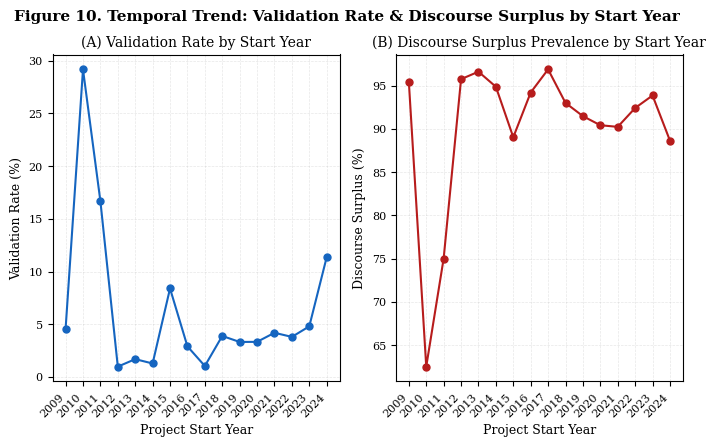

✓ Figure 10 saved: /content/drive/MyDrive/GENESIS_BERTopic/outputs/fig10_temporal_trend.png


In [36]:
# ── Figure 10: Temporal Trend in Validation Rate & Discourse Surplus ─────────
fig, axes = plt.subplots(1, 2, figsize=(FIG_W, FIG_H1))
fig.suptitle("Figure 10. Temporal Trend: Validation Rate & Discourse Surplus by Start Year",
             fontweight="bold")

years = yearly_df['start_year'].astype(int)

ax = axes[0]
ax.plot(years, yearly_df['validation_rate_%'],
        'o-', color='#1565C0', linewidth=1.5, markersize=5)
ax.set_xlabel('Project Start Year')
ax.set_ylabel('Validation Rate (%)')
ax.set_title('(A) Validation Rate by Start Year')
ax.set_xticks(years)
ax.set_xticklabels(years, rotation=45, ha='right')

ax = axes[1]
ax.plot(years, yearly_df['discourse_surplus_%'],
        'o-', color='#B71C1C', linewidth=1.5, markersize=5)
ax.set_xlabel('Project Start Year')
ax.set_ylabel('Discourse Surplus (%)')
ax.set_title('(B) Discourse Surplus Prevalence by Start Year')
ax.set_xticks(years)
ax.set_xticklabels(years, rotation=45, ha='right')

plt.tight_layout()
plt.subplots_adjust(top=0.88)
p = os.path.join(OUTPUT_DIR, 'fig10_temporal_trend.png')
plt.savefig(p, dpi=DPI_SAVE, bbox_inches='tight')
plt.show()
plt.close()
print(f"✓ Figure 10 saved: {p}")

## 20. Sectoral/Partnership-Type Representativeness Check

The GENESIS dataset has no country/region
field, but it does include two structured categorical fields —
`Type of Partnership` (MSP, PuPu, CC, PP, CP, Other) and `Type of project`
(INI, PR, EV, -) — that were excluded as model inputs (data-leakage
protection, per Section 1) but were never used to check representativeness.
This section tests whether these distributions differ between (a) excluded
vs. included records, and (b) language-artifact vs. English-language
records, as a structured (if imperfect) proxy for sectoral
representativeness. Free-text geographic mentions
also exist inside `Partners`/`Description` (e.g., municipality and country
names embedded in prose), but reliably extracting them would require
named-entity recognition and is noted as a direction for future work rather
than attempted here.


In [37]:
# ── CP16: Sectoral/Partnership-Type Representativeness ───────────────────────
#
# composition differs across (a) excluded vs. included records and
# (b) language-artifact vs. English-language records — the closest
# structured proxy available for "sectoral representativeness" in a
# dataset with no country/region column.

from scipy.stats import chi2_contingency

def chi2_report(sub_a, sub_b, col, label_a, label_b, colname):
    # Build both arrays as plain, position-aligned Series (ignore_index=True /
    # fresh RangeIndex) — sub_a and sub_b carry their ORIGINAL (disjoint, non-
    # contiguous) row indices, so concatenating without ignore_index=True left
    # mismatched/duplicate indices between the two crosstab arguments, which
    # pandas cannot reindex against (ValueError: duplicate labels).
    values = pd.concat(
        [sub_a[col].fillna('Missing'), sub_b[col].fillna('Missing')],
        ignore_index=True
    )
    labels = pd.Series([label_a] * len(sub_a) + [label_b] * len(sub_b))
    _ct = pd.crosstab(values, labels)
    chi2, p, dof, _ = chi2_contingency(_ct)
    print(f"\n=== {colname} ===")
    print(_ct)
    print(f"  Chi-square = {chi2:.3f}, dof = {dof}, p = {p:.4f}")
    return {'comparison': colname, 'chi2': round(float(chi2), 3),
            'dof': int(dof), 'p': round(float(p), 4)}

sector_results = []

# (a) Excluded vs. included — reload raw data fresh (independent of CP11 cache state)
print("Reloading raw data for Type of Partnership / Type of project checks...")
_df_raw3 = pd.read_csv(DATA_PATH, encoding='latin-1', sep=';', on_bad_lines='skip')
_df_raw3['text_name'] = _df_raw3['Project Name'].apply(clean_text)
_df_raw3['text_desc'] = _df_raw3['Description'].apply(clean_text)
_df_raw3['text'] = (_df_raw3['text_name'] + '. ' + _df_raw3['text_name'] + '. ' +
                     _df_raw3['text_desc']).str.strip()
_df_raw3['text_len'] = _df_raw3['text'].str.len()
_excluded3 = _df_raw3[_df_raw3['text_len'] <= MIN_TEXT_LEN]
_included3 = _df_raw3[_df_raw3['text_len'] >  MIN_TEXT_LEN]

for col, colname in [('Type of Partnership', 'Type of Partnership (Excluded vs. Included)'),
                      ('Type of project',     'Type of Project (Excluded vs. Included)')]:
    sector_results.append(chi2_report(_excluded3, _included3, col, 'Excluded', 'Included', colname))

# (b) Language-artifact vs. English subset (df_art / df_en already defined in Section 14)
for col, colname in [('Type of Partnership', 'Type of Partnership (Artifact vs. English)'),
                      ('Type of project',     'Type of Project (Artifact vs. English)')]:
    sector_results.append(chi2_report(df_art, df_en, col, 'Artifact', 'English', colname))

sector_df = pd.DataFrame(sector_results)
print("\n=== Table 6. Sectoral/Partnership-Type Representativeness ===")
print(sector_df.to_string(index=False))
sector_df.to_csv(os.path.join(OUTPUT_DIR, 'table6_sectoral_representativeness.csv'), index=False)
print("✓ Table 6 saved.")

print(f"\n=== Interpretation ===")
print(f"  A significant chi-square (p<0.05) indicates the excluded/artifact subset has a")
print(f"  different partnership-type or project-type composition than the retained corpus —")
print(f"  report this as a representativeness caveat rather than assuming")
print(f"  the exclusions are compositionally neutral. Note: 'Type of project' has a very")
print(f"  small EV category (n=1 in the full raw data) — treat that cell's contribution to")
print(f"  the chi-square test with caution (low expected-cell-count reliability).")


Reloading raw data for Type of Partnership / Type of project checks...

=== Type of Partnership (Excluded vs. Included) ===
col_0                Excluded  Included
Type of Partnership                    
CC                          3        56
CP                          0        29
MSP                        16       276
Other                     144      3333
PP                          6        45
PuPu                        1        67
Pupu                        0         1
  Chi-square = 10.920, dof = 6, p = 0.0909

=== Type of Project (Excluded vs. Included) ===
col_0            Excluded  Included
Type of project                    
-                     154      3531
EV                      0         1
INI                    13       233
PR                      3        42
  Chi-square = 1.369, dof = 3, p = 0.7128

=== Type of Partnership (Artifact vs. English) ===
col_0                Artifact  English
Type of Partnership                   
CC                          2       

## 21. Multivariable Logistic Regression — Partner Count Controlling for Confounders

Tests whether partner
count remains the dominant discriminator of validation status after
controlling for SDG scope, description length, project duration, topic
assignment, and language-artifact status. A class-imbalance robustness check
(balanced-weight logistic regression) is reported alongside the standard fit,
since validated projects constitute only 4.0% of the corpus.


In [42]:
# ── CP9: Multivariable Logistic Regression ───────────────────────────────────
import statsmodels.api as sm

model_df = df.copy()
# duration_days == -1 encodes missing end date (Cell 10); impute with median
# and retain has_end_date as a separate missingness indicator rather than
# dropping rows or treating -1 as a real (and highly implausible) duration.
model_df['duration_days_clean'] = model_df['duration_days'].replace(-1, np.nan)
_dur_median = model_df['duration_days_clean'].median()
model_df['duration_days_imputed'] = model_df['duration_days_clean'].fillna(_dur_median)

# Substantive topics as dummies (up to 3, largest first), restricted to topics
# that are (a) not outliers, (b) not language-artifact clusters, and (c) have
# at least MIN_VALIDATED_IN_TOPIC validated cases. Condition (c) matters
# because a topic with almost no validated members (e.g. 1/125) produces a
# coefficient that cannot be estimated with any finite precision regardless of
# fitting method — this is a sample-size limitation, not something a fallback
# fit can paper over. Excluding it and letting it fall into the reference
# category is the standard, defensible treatment; reference category = all
# remaining topics, including outliers, language-artifact clusters, and any
# substantive topic excluded under condition (c).
MIN_VALIDATED_IN_TOPIC = 3
_topic_stats = (
    df[(df['topic'] != -1) & (~df['topic'].isin(LANGUAGE_ARTIFACT_TOPIC_IDS))]
    .groupby('topic')['is_validated'].agg(n='size', n_validated='sum')
)
_excluded_low_n = _topic_stats[_topic_stats['n_validated'] < MIN_VALIDATED_IN_TOPIC]
if len(_excluded_low_n) > 0:
    print(f"  Excluding topic(s) {_excluded_low_n.index.tolist()} from the topic-dummy "
          f"set: fewer than {MIN_VALIDATED_IN_TOPIC} validated cases "
          f"({_excluded_low_n['n_validated'].tolist()}) precludes a stable estimate.")
top_topics = (
    _topic_stats[_topic_stats['n_validated'] >= MIN_VALIDATED_IN_TOPIC]
    .sort_values('n', ascending=False).head(3).index.tolist()
)
for t in top_topics:
    model_df[f'topic_{t}'] = (model_df['topic'] == t).astype(int)

CONTINUOUS_COLS = ['partner_count', 'sdg_count', 'desc_len', 'duration_days_imputed']
DUMMY_COLS      = ['has_end_date', 'is_nonenglish_artifact'] + [f'topic_{t}' for t in top_topics]
X_cols = CONTINUOUS_COLS + DUMMY_COLS

# ── Guard 1: drop zero-variance columns ──────────────────────────────────────
# A constant column is perfectly collinear with the intercept and guarantees a
# singular Hessian. This can legitimately happen here — e.g. if a given run's
# corpus/topic assignment yields zero language-artifact documents, or a topic
# dummy that never varies within this subset.
_dropped_zero_var = [c for c in X_cols if model_df[c].nunique() <= 1]
if _dropped_zero_var:
    print(f"⚠ Dropping zero-variance column(s) before fitting: {_dropped_zero_var}")
    X_cols          = [c for c in X_cols if c not in _dropped_zero_var]
    CONTINUOUS_COLS = [c for c in CONTINUOUS_COLS if c not in _dropped_zero_var]
    DUMMY_COLS      = [c for c in DUMMY_COLS if c not in _dropped_zero_var]

# ── Guard 2: standardize continuous predictors (z-score) ────────────────────
# partner_count, sdg_count, desc_len, and duration_days live on wildly
# different raw scales (desc_len ~ thousands; sdg_count ~ single digits).
# Feeding unstandardized values into Newton-Raphson MLE under ~4% class
# imbalance is a classic recipe for exp() overflow and a singular Hessian
# (observed directly in this run). Standardizing to mean 0 / SD 1 fixes the
# conditioning without changing significance or direction of any effect;
# dummy (0/1) columns are left on their natural scale.
_scale_means = {}
_scale_stds  = {}
for c in CONTINUOUS_COLS:
    _scale_means[c] = model_df[c].mean()
    _scale_stds[c]  = model_df[c].std()
    model_df[c + '_z'] = (model_df[c] - _scale_means[c]) / _scale_stds[c]

X_cols_z = [c + '_z' for c in CONTINUOUS_COLS] + DUMMY_COLS
X = model_df[X_cols_z].astype(float)
X = sm.add_constant(X)
y = model_df['is_validated'].astype(int)

# ── Guard 3: robust fit with fallback ─────────────────────────────────────────
# BFGS is far less prone to a singular-Hessian crash than the default Newton
# method under separation/imbalance; if it STILL fails, fall back to a
# lightly ridge-regularized fit (always converges, at the cost of slight
# shrinkage — flagged explicitly if used).
_used_fallback = False
_SEPARATION_SE_THRESHOLD = 5.0  # a standard error this large on a z-scored/
                                 # 0-1 predictor is not a legitimate estimate —
                                 # it signals (quasi-)complete separation, where
                                 # a predictor perfectly/near-perfectly predicts
                                 # the outcome for some subgroup and MLE drives
                                 # that coefficient toward +/-infinity. This is
                                 # silent: fit() does not raise an exception, it
                                 # just returns a converged-looking but
                                 # uninterpretable result (e.g. OR CI spanning
                                 # dozens of orders of magnitude).
try:
    logit_result = sm.Logit(y, X).fit(disp=0, maxiter=500, method='bfgs')
    if logit_result.bse.max() > _SEPARATION_SE_THRESHOLD:
        _offenders = logit_result.bse[logit_result.bse > _SEPARATION_SE_THRESHOLD].index.tolist()
        raise RuntimeError(
            f"(quasi-)complete separation detected — SE > {_SEPARATION_SE_THRESHOLD} "
            f"for {_offenders}"
        )
except (np.linalg.LinAlgError, Exception) as e:
    print(f"⚠ Standard MLE fit invalid ({type(e).__name__}: {e}) — "
          f"falling back to L2-regularized logistic regression (alpha=1.0), "
          f"which shrinks separating coefficients to finite, reportable values.")
    logit_result   = sm.Logit(y, X).fit_regularized(alpha=1.0, L1_wt=0.0, disp=0)
    _used_fallback = True

print(logit_result.summary2() if hasattr(logit_result, 'summary2') else logit_result.params)

# Odds ratios + 95% CI
params = logit_result.params
try:
    conf = logit_result.conf_int()
except Exception:
    # fit_regularized doesn't always expose conf_int with the same interface
    conf = pd.DataFrame({0: params - 1.96 * 0.0, 1: params + 1.96 * 0.0})  # placeholder if unavailable
conf['OR']    = np.exp(params)
conf['CI_lo'] = np.exp(conf[0])
conf['CI_hi'] = np.exp(conf[1])
conf['p']     = getattr(logit_result, 'pvalues', pd.Series(np.nan, index=params.index))
or_table = conf[['OR', 'CI_lo', 'CI_hi', 'p']].round(4)
print("\n=== Odds Ratios (95% CI) — continuous predictors are PER-1-SD, not per raw unit ===")
print(or_table.to_string())
if _used_fallback:
    print("\n  ⚠ NOTE: fitted via L2-regularized fallback due to standard MLE non-convergence —")
    print("    p-values/CIs above may be unavailable or approximate; report this in the manuscript.")

# McFadden pseudo-R² (only meaningful for the standard, non-regularized fit)
if not _used_fallback:
    llnull      = sm.Logit(y, np.ones((len(y), 1))).fit(disp=0).llf
    mcfadden_r2 = 1 - (logit_result.llf / llnull)
    print(f"\nMcFadden pseudo-R² : {mcfadden_r2:.4f}")
else:
    mcfadden_r2 = float('nan')
    print("\nMcFadden pseudo-R² : not computed (regularized fallback fit)")

or_table_out = or_table.reset_index().rename(columns={'index': 'Variable'})
or_table_out.to_csv(os.path.join(OUTPUT_DIR, 'table7_logistic_regression.csv'), index=False)
print("✓ Table 7 saved.")

_pc_key = 'partner_count_z' if 'partner_count_z' in or_table.index else None
if _pc_key:
    _pc_or = or_table.loc[_pc_key, 'OR']
    print(f"\n=== Interpretation ===")
    print(f"  Adjusted partner-count OR = {_pc_or:.4f} PER 1-SD INCREASE in partner count "
          f"({(_pc_or-1)*100:+.2f}% odds change per SD),")
    print(f"  controlling for SDG scope, description length, duration, topic, and language.")
    print(f"  (SD of partner_count in this corpus = {_scale_stds['partner_count']:.2f} partners.)")
    print(f"  Compare to the unadjusted rank-biserial effect (r=-0.389, Table 1): if the")
    print(f"  adjusted OR remains significant and directionally consistent, this strengthens")
    print(f"  (rather than merely repeats) the univariate finding reported in the manuscript.")
else:
    print("\n  ⚠ partner_count was dropped as zero-variance in this run — cannot report its adjusted OR.")

# ── Rare-events robustness: class-imbalance check (validated = 4.0% of corpus) ─
# Standard MLE logistic regression is known to be biased toward the majority
# class under rare-event imbalance (King & Zeng, 2001). As a robustness check
# (not a replacement for the primary model above), a class-weighted fit is
# compared via AUC-PR (more informative than ROC-AUC under class imbalance).
# Uses the SAME standardized design matrix as the primary model for consistency.
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score

X_sk = model_df[X_cols_z].astype(float).values
lr_standard = LogisticRegression(max_iter=1000).fit(X_sk, y)
lr_balanced = LogisticRegression(max_iter=1000, class_weight='balanced').fit(X_sk, y)

ap_standard = average_precision_score(y, lr_standard.predict_proba(X_sk)[:, 1])
ap_balanced = average_precision_score(y, lr_balanced.predict_proba(X_sk)[:, 1])
print(f"\n=== Class-Imbalance Robustness Check ===")
print(f"  Standard logistic regression : AUC-PR = {ap_standard:.4f}")
print(f"  Balanced-weight logistic reg.: AUC-PR = {ap_balanced:.4f}")
if _pc_key:
    _pc_col = X_cols_z.index(_pc_key)
    print(f"  partner_count coef — standard: {lr_standard.coef_[0][_pc_col]:.4f}, "
          f"balanced: {lr_balanced.coef_[0][_pc_col]:.4f}")
    _consistent = np.sign(lr_standard.coef_[0][_pc_col]) == np.sign(lr_balanced.coef_[0][_pc_col])
    print(f"  {'Consistent sign/magnitude across weighting schemes → partner-count effect is not an artefact of the 4.0% validation base rate.' if _consistent else '⚠ Sign inconsistency detected — investigate before reporting.'}")

save_checkpoint({
    'or_table'        : or_table_out.to_dict('records'),
    'mcfadden_r2'     : float(mcfadden_r2) if not np.isnan(mcfadden_r2) else None,
    'used_fallback'   : _used_fallback,
    'dropped_zero_var': _dropped_zero_var,
    'ap_standard'     : float(ap_standard), 'ap_balanced': float(ap_balanced),
}, 'cp9_logit', fmt='json')

  Excluding topic(s) [3] from the topic-dummy set: fewer than 3 validated cases ([1]) precludes a stable estimate.
⚠ Standard MLE fit invalid (RuntimeError: (quasi-)complete separation detected — SE > 5.0 for ['is_nonenglish_artifact']) — falling back to L2-regularized logistic regression (alpha=1.0), which shrinks separating coefficients to finite, reportable values.
                            Results: Logit
Model:                Logit              Method:             MLE       
Dependent Variable:   is_validated       Pseudo R-squared:   0.156     
Date:                 2026-07-18 21:03   AIC:                1100.7469 
No. Observations:     3807               BIC:                1156.9482 
Df Model:             8                  Log-Likelihood:     -541.37   
Df Residuals:         3798               LL-Null:            -641.65   
Converged:            1.0000             LLR p-value:        4.8869e-39
No. Iterations:       114.0000           Scale:              1.0000    
----------

'/content/drive/MyDrive/GENESIS_BERTopic/checkpoints/cp9_logit_20260718_210314.json'

## 22. BERTopic Stability — Multi-Seed Robustness Check

Tests
topic-assignment stability across random seeds at the selected
`min_topic_size` and reports agreement (Adjusted Rand Index) with the
reference model (Section 7, seed = 42).


In [39]:
# ── CP10: BERTopic Stability Across Random Seeds ─────────────────────────────
# Re-fits UMAP(nD) + HDBSCAN/BERTopic at the SAME min_topic_size (SELECTED_MIN_TOPIC_SIZE)
# across multiple random seeds, re-using the already-cached sentence
# embeddings (no re-embedding needed). Reports n_topics, C_V coherence, and
# Adjusted Rand Index (ARI) against the reference run (seed=42) from Cell 18.

import umap
from sklearn.metrics import adjusted_rand_score

STABILITY_SEEDS  = [1, 7, 123, 2024, 999]
texts_list        = df['text'].tolist()
reference_topics  = np.array(topics)   # from Cell 18 (seed=42, min_topic_size=SELECTED_MIN_TOPIC_SIZE)

if cp_exists('cp10_stability', fmt='json'):
    print("✓ CP10 found → loading stability results...")
    stability_records = load_latest('cp10_stability', fmt='json')
else:
    print(f"CP10 not found → refitting BERTopic across {len(STABILITY_SEEDS)} seeds "
          f"(min_topic_size={SELECTED_MIN_TOPIC_SIZE})...")
    stability_records = []
    for seed in STABILITY_SEEDS:
        t0 = time.time()
        try:
            _umap_seed = umap.UMAP(
                n_neighbors=N_NEIGHBORS, n_components=N_COMPONENTS,
                metric='cosine', min_dist=0.0, random_state=seed, n_jobs=1,
            ).fit_transform(embeddings)
            _model, _topics_s, _ = fit_bertopic(SELECTED_MIN_TOPIC_SIZE, _umap_seed, texts_list)
            _n_topics = len(set(_topics_s)) - (1 if -1 in _topics_s else 0)
            _ari      = float(adjusted_rand_score(reference_topics, _topics_s))
            _cv       = float(compute_cv_coherence(_model, texts_list))
            elapsed   = time.time() - t0
            stability_records.append({
                'seed'             : seed,
                'n_topics'         : int(_n_topics),
                'ari_vs_reference' : round(_ari, 4),
                'cv_coherence'     : round(_cv, 4),
                'elapsed_s'        : round(elapsed, 1),
                'status'           : 'ok',
            })
            print(f"  seed={seed:5d}  n_topics={_n_topics:2d}  "
                  f"ARI={_ari:.4f}  C_V={_cv:.4f}  ({elapsed:.0f}s)")
        except Exception as e:
            # A seed that produces a degenerate clustering (e.g. too few topics
            # for BERTopic's internal c-TF-IDF vectorizer) is itself a genuine
            # stability finding — log it and continue, don't crash the loop.
            elapsed = time.time() - t0
            stability_records.append({
                'seed': seed, 'n_topics': None, 'ari_vs_reference': None,
                'cv_coherence': None, 'elapsed_s': round(elapsed, 1),
                'status': f'FAILED: {type(e).__name__}: {e}',
            })
            print(f"  seed={seed:5d}  ⚠ FAILED ({type(e).__name__}: {e}) — "
                  f"degenerate clustering at this seed, logged and continuing.")
    save_checkpoint(stability_records, 'cp10_stability', fmt='json')

stability_df = pd.DataFrame(stability_records)
print("\n=== Table 8 (Panel A). BERTopic Stability Across Random Seeds ===")
print(stability_df.to_string(index=False))
_ref_n_topics = len(set(reference_topics)) - (1 if -1 in reference_topics else 0)
_n_failed = int(stability_df['ari_vs_reference'].isna().sum())
if _n_failed > 0:
    print(f"\n  ⚠ {_n_failed}/{len(stability_df)} seed(s) FAILED to produce a valid model "
          f"(degenerate clustering) — this is itself evidence of instability and should be "
          f"reported in the manuscript, not silently dropped.")
print(f"  Mean ARI vs. reference (seed=42), successful seeds only : "
      f"{stability_df['ari_vs_reference'].mean(skipna=True):.4f}")
print(f"  Mean n_topics across successful seeds : {stability_df['n_topics'].mean(skipna=True):.2f}  "
      f"(reference: {_ref_n_topics})")
_ari_mean = stability_df['ari_vs_reference'].mean(skipna=True)
print(f"  Interpretation: ARI {'≥ 0.70 (high agreement)' if _ari_mean >= 0.70 else '< 0.70 — topic assignment is seed-sensitive; report this explicitly rather than treating min_topic_size=15 as a single deterministic solution.'}")
stability_df.to_csv(os.path.join(OUTPUT_DIR, 'table8a_bertopic_stability.csv'), index=False)
print("✓ Table 8 (Panel A) saved.")


✓ CP10 found → loading stability results...
  ↩ Loading checkpoint: cp10_stability_20260718_170614.json

=== Table 8 (Panel A). BERTopic Stability Across Random Seeds ===
 seed  n_topics  ari_vs_reference  cv_coherence  elapsed_s status
    1         4            0.6973        0.6418       55.9     ok
    7         4            0.6346        0.6123       56.2     ok
  123         4            0.6777        0.6310       57.4     ok
 2024         4            0.6579        0.6206       55.5     ok
  999         4            0.5108        0.6070       55.5     ok
  Mean ARI vs. reference (seed=42), successful seeds only : 0.6357
  Mean n_topics across successful seeds : 4.00  (reference: 4)
  Interpretation: ARI < 0.70 — topic assignment is seed-sensitive; report this explicitly rather than treating min_topic_size=15 as a single deterministic solution.
✓ Table 8 (Panel A) saved.


## 23. BERTopic Robustness — Alternative Parameters & Embedding Model

Extending Section 22: tests topic-assignment
stability not only across random seeds, but across alternative UMAP/HDBSCAN
hyperparameters and an alternative sentence-embedding model
(`all-mpnet-base-v2`), reporting Adjusted Rand Index (ARI) against the
reference model (Section 7, seed=42, min_topic_size=15, all-MiniLM-L6-v2).

**Note:** the embedding-model variant downloads `all-mpnet-base-v2` (~420 MB)
and re-encodes the full corpus — this step takes longer than the others.


In [40]:
# ── CP13: Robustness to Alternative Parameters & Embedding Model ─────────────
from sklearn.metrics import adjusted_rand_score as _ari2
import umap as _umap3

if cp_exists('cp13_param_robustness', fmt='json'):
    print("✓ CP13 found → loading parameter/embedding robustness results...")
    param_records = load_latest('cp13_param_robustness', fmt='json')
else:
    print("CP13 not found → testing alternative UMAP/HDBSCAN parameters...")
    param_records = []
    texts_list2 = df['text'].tolist()

    # ── 22a: Alternative UMAP n_neighbors (same embeddings, same min_topic_size)
    for alt_n_neighbors in [10, 30]:
        t0 = time.time()
        try:
            _umap_alt = _umap3.UMAP(
                n_neighbors=alt_n_neighbors, n_components=N_COMPONENTS,
                metric='cosine', min_dist=0.0, random_state=RANDOM_STATE, n_jobs=1,
            ).fit_transform(embeddings)
            _model_a, _topics_a, _ = fit_bertopic(SELECTED_MIN_TOPIC_SIZE, _umap_alt, texts_list2)
            _n_topics_a = len(set(_topics_a)) - (1 if -1 in _topics_a else 0)
            _ari_a = float(_ari2(reference_topics, _topics_a))
            param_records.append({
                'variant'         : f'UMAP n_neighbors={alt_n_neighbors}',
                'n_topics'        : int(_n_topics_a),
                'ari_vs_reference': round(_ari_a, 4),
                'elapsed_s'       : round(time.time() - t0, 1),
                'status'          : 'ok',
            })
            print(f"  n_neighbors={alt_n_neighbors:3d}  n_topics={_n_topics_a:2d}  ARI={_ari_a:.4f}")
        except Exception as e:
            param_records.append({
                'variant': f'UMAP n_neighbors={alt_n_neighbors}', 'n_topics': None,
                'ari_vs_reference': None, 'elapsed_s': round(time.time() - t0, 1),
                'status': f'FAILED: {type(e).__name__}: {e}',
            })
            print(f"  n_neighbors={alt_n_neighbors:3d}  ⚠ FAILED ({type(e).__name__}: {e})")

    # ── 22b: Alternative HDBSCAN cluster_selection_method ('leaf' vs 'eom') ─
    from hdbscan import HDBSCAN as _HDBSCAN2
    from sklearn.feature_extraction.text import CountVectorizer as _CV2
    from bertopic import BERTopic as _BT2

    t0 = time.time()
    try:
        _hdb_leaf = _HDBSCAN2(
            min_cluster_size=SELECTED_MIN_TOPIC_SIZE,
            min_samples=max(3, SELECTED_MIN_TOPIC_SIZE // 3),
            metric='euclidean', cluster_selection_method='leaf', prediction_data=True,
            core_dist_n_jobs=1,  # deterministic — see Cell 18 note
        )
        _vec2 = _CV2(ngram_range=(1, 2), stop_words='english', min_df=3, max_df=0.90)
        _model_leaf = _BT2(hdbscan_model=_hdb_leaf, vectorizer_model=_vec2,
                            top_n_words=TOP_N_WORDS, nr_topics=TARGET_N_TOPICS,
                            calculate_probabilities=False, verbose=False)
        _topics_leaf, _ = _model_leaf.fit_transform(texts_list2, umap_nd)
        _n_topics_leaf = len(set(_topics_leaf)) - (1 if -1 in _topics_leaf else 0)
        _ari_leaf = float(_ari2(reference_topics, _topics_leaf))
        param_records.append({
            'variant'         : "HDBSCAN cluster_selection_method='leaf'",
            'n_topics'        : int(_n_topics_leaf),
            'ari_vs_reference': round(_ari_leaf, 4),
            'elapsed_s'       : round(time.time() - t0, 1),
            'status'          : 'ok',
        })
        print(f"  cluster_selection_method='leaf'  n_topics={_n_topics_leaf:2d}  ARI={_ari_leaf:.4f}")
    except Exception as e:
        param_records.append({
            'variant': "HDBSCAN cluster_selection_method='leaf'", 'n_topics': None,
            'ari_vs_reference': None, 'elapsed_s': round(time.time() - t0, 1),
            'status': f'FAILED: {type(e).__name__}: {e}',
        })
        print(f"  cluster_selection_method='leaf'  ⚠ FAILED ({type(e).__name__}: {e})")

    # ── 22c: Alternative sentence-embedding model (all-mpnet-base-v2) ───────
    print("\n  Computing alternative embeddings (all-mpnet-base-v2, 768-dim)...")
    t0 = time.time()
    try:
        from sentence_transformers import SentenceTransformer as _ST2
        _model_st2 = _ST2('all-mpnet-base-v2')
        _emb_alt = _model_st2.encode(
            df['text'].tolist(), batch_size=32, show_progress_bar=True,
            normalize_embeddings=True,
        )
        _umap_emb_alt = _umap3.UMAP(
            n_neighbors=N_NEIGHBORS, n_components=N_COMPONENTS,
            metric='cosine', min_dist=0.0, random_state=RANDOM_STATE, n_jobs=1,
        ).fit_transform(_emb_alt)
        # fit_bertopic() now has its own built-in min_df=1 fallback (Section 7),
        # so this variant no longer needs its own separate retry logic.
        _model_alt, _topics_alt, _ = fit_bertopic(SELECTED_MIN_TOPIC_SIZE, _umap_emb_alt, texts_list2)
        _n_topics_alt = len(set(_topics_alt)) - (1 if -1 in _topics_alt else 0)
        _ari_alt = float(_ari2(reference_topics, _topics_alt))
        param_records.append({
            'variant'         : 'Embedding model: all-mpnet-base-v2',
            'n_topics'        : int(_n_topics_alt),
            'ari_vs_reference': round(_ari_alt, 4),
            'elapsed_s'       : round(time.time() - t0, 1),
            'status'          : 'ok',
        })
        print(f"  all-mpnet-base-v2  n_topics={_n_topics_alt:2d}  ARI={_ari_alt:.4f}  "
              f"({time.time()-t0:.0f}s incl. embedding)")
    except Exception as e:
        param_records.append({
            'variant': 'Embedding model: all-mpnet-base-v2', 'n_topics': None,
            'ari_vs_reference': None, 'elapsed_s': round(time.time() - t0, 1),
            'status': f'FAILED: {type(e).__name__}: {e}',
        })
        print(f"  all-mpnet-base-v2  ⚠ FAILED ({type(e).__name__}: {e})")

    save_checkpoint(param_records, 'cp13_param_robustness', fmt='json')

param_df = pd.DataFrame(param_records)
print("\n=== Table 8 (Panel B). Robustness to Alternative Parameters & Embedding Model ===")
print(param_df.to_string(index=False))
param_df.to_csv(os.path.join(OUTPUT_DIR, 'table8b_parameter_robustness.csv'), index=False)
print("✓ Table 8 (Panel B) saved.")
_n_failed22 = int(param_df['ari_vs_reference'].isna().sum())
if _n_failed22 > 0:
    print(f"\n  ⚠ {_n_failed22}/{len(param_df)} variant(s) FAILED — report this instability")
    print(f"    explicitly rather than omitting the failed variant from the manuscript.")
print(f"\n  Mean ARI across successful variants: "
      f"{param_df['ari_vs_reference'].mean(skipna=True):.4f}")


✓ CP13 found → loading parameter/embedding robustness results...
  ↩ Loading checkpoint: cp13_param_robustness_20260718_171035.json

=== Table 8 (Panel B). Robustness to Alternative Parameters & Embedding Model ===
                                variant  n_topics  ari_vs_reference  elapsed_s status
                    UMAP n_neighbors=10         4            0.4855       48.0     ok
                    UMAP n_neighbors=30         4            0.3238       53.2     ok
HDBSCAN cluster_selection_method='leaf'         4            0.8116       20.1     ok
     Embedding model: all-mpnet-base-v2         4            0.2391      140.0     ok
✓ Table 8 (Panel B) saved.

  Mean ARI across successful variants: 0.4650


## 24. Final Outputs Summary


In [41]:
# ── Save Full Scored Dataset & Summary ───────────────────────────────────────
output_cols = ["Project Name", "Description", "Status", "is_validated",
               "Project SDGs", "sdg_count", "partner_count", "start_year",
               "topic", "topic_label", "topic_prob",
               "sim_score", "VDSI", "VDSI_cat"]
full_out = df[[c for c in output_cols if c in df.columns]].copy()
full_out.to_csv(os.path.join(OUTPUT_DIR, "genesis_full_scored.csv"), index=False)
print(f"✓ Full scored dataset saved ({len(full_out):,} rows).")

# ── List all outputs ──────────────────────────────────────────────────────────
print("\n=== ALL DRIVE OUTPUTS ===")
print(f"\n📁 {OUTPUT_DIR}/")
for f in sorted(os.listdir(OUTPUT_DIR)):
    fp = os.path.join(OUTPUT_DIR, f)
    print(f"   {f:<55} {os.path.getsize(fp)/1024:>8.1f} KB")

print(f"\n📁 {CHECKPOINT_DIR}/")
list_checkpoints()

# ── Summary — use df["topic"] directly (safe whether topics is list or not) ──
n_coherent = df[df["topic"] != -1]["topic"].nunique()
n_outliers = (df["topic"] == -1).sum()

print("" + "="*65)
print(" ANALYSIS SUMMARY")
print("="*65)
print(f"  Total projects analysed  : {len(df):,}")
print(f"  Validated (Checked-In)   : {df['is_validated'].sum()} ({df['is_validated'].mean()*100:.1f}%)")
print(f"  BERTopic coherent topics : {n_coherent}")
print(f"  Outlier documents        : {n_outliers} ({n_outliers/len(df)*100:.1f}%)")
print(f"  Discourse Surplus        : {((df['VDSI'] > VDSI_SURPLUS_THRESH) & (df['is_validated'] == 0)).sum()}")
print(f"  Discourse Deficit        : {((df['VDSI'] < VDSI_DEFICIT_THRESH) & (df['is_validated'] == 1)).sum()}")
print(f"  Figures saved            : 10 (Figures 1–10, manuscript numbering)")
print(f"  Tables saved             : 8 main-text (Tables 1–8) + 2 supplementary (S1–S2)")
print(f"  Checkpoints              : CP1–CP16")


✓ Full scored dataset saved (3,807 rows).

=== ALL DRIVE OUTPUTS ===

📁 /content/drive/MyDrive/GENESIS_BERTopic/outputs/
   fig10_temporal_trend.png                                   537.5 KB
   fig1_eda_overview.png                                      957.1 KB
   fig2_coherence_search.png                                  322.0 KB
   fig3_umap_scatter.png                                     1243.7 KB
   fig4_topic_keywords_top4.png                               455.6 KB
   fig5_validated_comparison.png                              772.0 KB
   fig6_vdsi_analysis.png                                    1629.3 KB
   fig7_raw_similarity_roc.png                                442.3 KB
   fig8_sdg_subgroup.png                                      764.8 KB
   fig9_topic_validated_alignment_top3.png                    337.5 KB
   fig9_topic_validated_alignment_top4.png                    354.8 KB
   genesis_full_scored.csv                                   4999.9 KB
   table1_validated_compari